# 6CS012 — Final Portfolio Assessment 2026
## Part II: Image Classification with Convolutional Neural Networks
### Dataset: Fruits Classification (Apple, Banana, Grape, Mango, Strawberry)

---
**Student:** `[Krishma Shrestha — 2431161]`  
**Date:** May 10 2026  
---

## Section 0: Initial Project Setup — Environment Configuration and Dataset Preparation

This section covers the foundational steps to prepare the development environment and acquire the dataset.  
It installs required libraries, uploads the dataset, and extracts it — ensuring all prerequisites are met before data analysis and model development begin.

In [1]:
from google.colab import files

# Uploading the dataset zip file.
# Here I am uploading the 'Fruits Classification.zip' file.
uploaded = files.upload()

Saving Fruits Classification.zip to Fruits Classification.zip


In [2]:
import os

# Identifying the uploaded zip file to proceed with extraction.
# This step confirms if the dataset was successfully provided.
if uploaded:
    uploaded_filename = next(iter(uploaded)) # Retrieving the filename of the uploaded dataset.
    zip_path = os.path.join('/content', uploaded_filename)
    print(f"Using uploaded zip file: {zip_path}")
else:
    print("No file was uploaded. Please make sure to upload 'Fruits Classification.zip' in the previous cell.")
    zip_path = None # Setting zip_path to None if no file was uploaded, for error handling.

Using uploaded zip file: /content/Fruits Classification.zip


In [3]:
import zipfile
import os

# Defining the directory where the dataset contents will be extracted.
extract_path = '/content/fruits_dataset'

# Extracting all files from the uploaded zip archive into the specified directory.
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/fruits_dataset


In [4]:
# Installing required libraries (uncomment if running in a new Colab session).
# !pip install -q tensorflow scikit-learn matplotlib seaborn

# Mounting Google Drive to access persistent storage for models or data (if needed).
# from google.colab import drive
# drive.mount('/content/drive')

# Importing essential standard libraries for general programming tasks.
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Importing TensorFlow and Keras modules for building and training neural networks.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 # Utilizing VGG16 for transfer learning.
from tensorflow.keras.optimizers import Adam, SGD

# Importing Scikit-learn for evaluating model performance with various metrics.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Setting random seeds to ensure reproducibility of experiments.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Displaying the versions of key libraries and hardware information.
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")
print("Environment ready ✓")

TensorFlow version : 2.20.0
GPU available      : True
Environment ready ✓


## Section 1: Global Project Configuration

This section defines all global parameters used consistently throughout the project:  
dataset paths, image dimensions, batch sizes, class names, and epoch counts.

In [5]:
import os

# Defining the paths to the dataset splits.
# BASE_DIR should point to the main folder containing 'train', 'valid', and 'test' subdirectories.
BASE_DIR   = '/content/fruits_dataset/Fruits Classification'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VALID_DIR  = os.path.join(BASE_DIR, 'valid')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# Setting up image dimensions and batch size for consistency across models.
IMG_SIZE_BASELINE = (64, 64)    # Dimensions for baseline and deeper CNN models.
IMG_SIZE_TL       = (224, 224)  # Dimensions for transfer learning models (VGG16 requires 224x224).
BATCH_SIZE        = 32

# Dynamically identifying class names from the training directory.
# This ensures the model correctly recognizes all categories.
CLASSES           = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES       = len(CLASSES)

# Specifying the number of training epochs for each model type.
EPOCHS_BASELINE = 30
EPOCHS_DEEPER   = 40
EPOCHS_TL       = 20

# Displaying the detected classes and batch size for verification.
print(f"Detected Classes ({NUM_CLASSES}): {CLASSES}")
print(f"Configured Batch Size: {BATCH_SIZE}")

Detected Classes (5): ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Configured Batch Size: 32


## Section 2: Data Understanding, Analysis, Visualization, and Cleaning
*(Addresses Assessment Task 2.5.1)*

Before building models, we perform a thorough Exploratory Data Analysis (EDA) to understand the dataset structure, class distribution, and image characteristics.  
This section also documents all preprocessing and augmentation strategies applied.

### Questions Addressed:
- What does the dataset represent?
- How many total images are in the dataset?
- What is the distribution of images across classes?
- How is the dataset split into training and validation sets?
- What preprocessing techniques were applied?
- What data generators were used?
- Visualizations of sample and augmented images.

### 2.1 Dataset Description

The dataset contains images of five fruit categories: **Apple, Banana, Grape, Mango, and Strawberry**.  
Images are pre-split into `train`, `valid`, and `test` directories, with each subdirectory organized by class label.  
The dataset is well-balanced — each class has an equal number of images in each split, preventing class bias.

In [6]:
# ── 2.1.1  Count images per split per class ───────────────────────────────────
def count_images(root_dir):
    """Return {class_name: count} for all image files under root_dir."""
    counts = {}
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if os.path.isdir(cls_path):
            n = sum(
                1 for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            )
            counts[cls] = n
    return counts

train_counts = count_images(TRAIN_DIR)
valid_counts = count_images(VALID_DIR)
test_counts  = count_images(TEST_DIR)

print("=" * 52)
print(f"{'Class':<14} {'Train':>8} {'Valid':>8} {'Test':>8} {'Total':>8}")
print("-" * 52)
for cls in CLASSES:
    tr = train_counts.get(cls, 0)
    va = valid_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    print(f"{cls:<14} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")
print("-" * 52)
total_tr = sum(train_counts.values())
total_va = sum(valid_counts.values())
total_te = sum(test_counts.values())
grand    = total_tr + total_va + total_te
print(f"{'TOTAL':<14} {total_tr:>8} {total_va:>8} {total_te:>8} {grand:>8}")
print("=" * 52)

Class             Train    Valid     Test    Total
----------------------------------------------------
Apple              1940       40       20     2000
Banana             1940       40       20     2000
Grape              1940       40       20     2000
Mango              1940       40       20     2000
Strawberry         1940       40       20     2000
----------------------------------------------------
TOTAL              9700      200      100    10000


### 2.2 Class Distribution Visualization

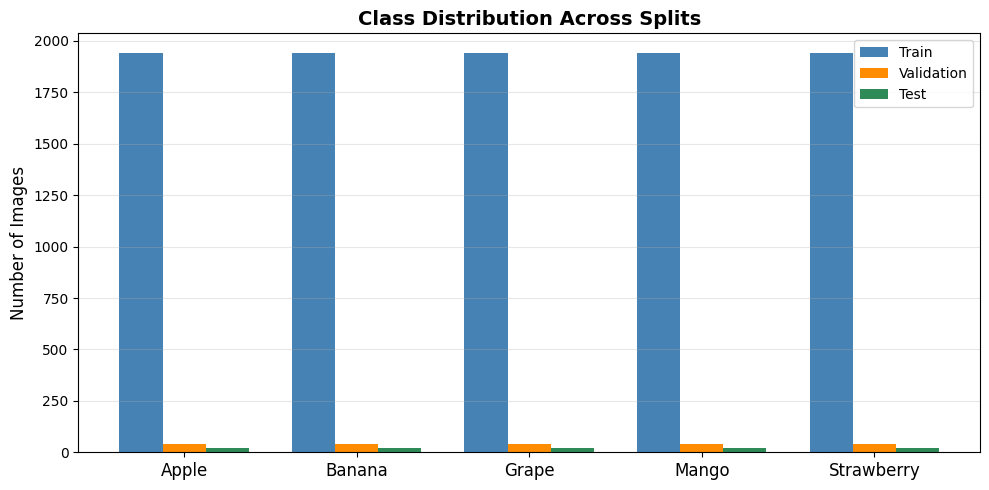

Figure 1: Class Distribution Across Splits


In [7]:
# ── 2.1.2  Class-distribution bar chart ──────────────────────────────────────
x        = np.arange(NUM_CLASSES)
width    = 0.25
tr_vals  = [train_counts[c] for c in CLASSES]
va_vals  = [valid_counts[c] for c in CLASSES]
te_vals  = [test_counts[c]  for c in CLASSES]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, tr_vals, width, label='Train',      color='steelblue')
ax.bar(x,         va_vals, width, label='Validation', color='darkorange')
ax.bar(x + width, te_vals, width, label='Test',       color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution Across Splits', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Figure 1: Class Distribution Across Splits")

#### Figure 1: Class Distribution Across Splits

This bar chart confirms the dataset is well-balanced, with equal numbers of images per class across training, validation, and test splits.  
This prevents any bias towards a particular class during training or evaluation.

### 2.3 Sample Training Images

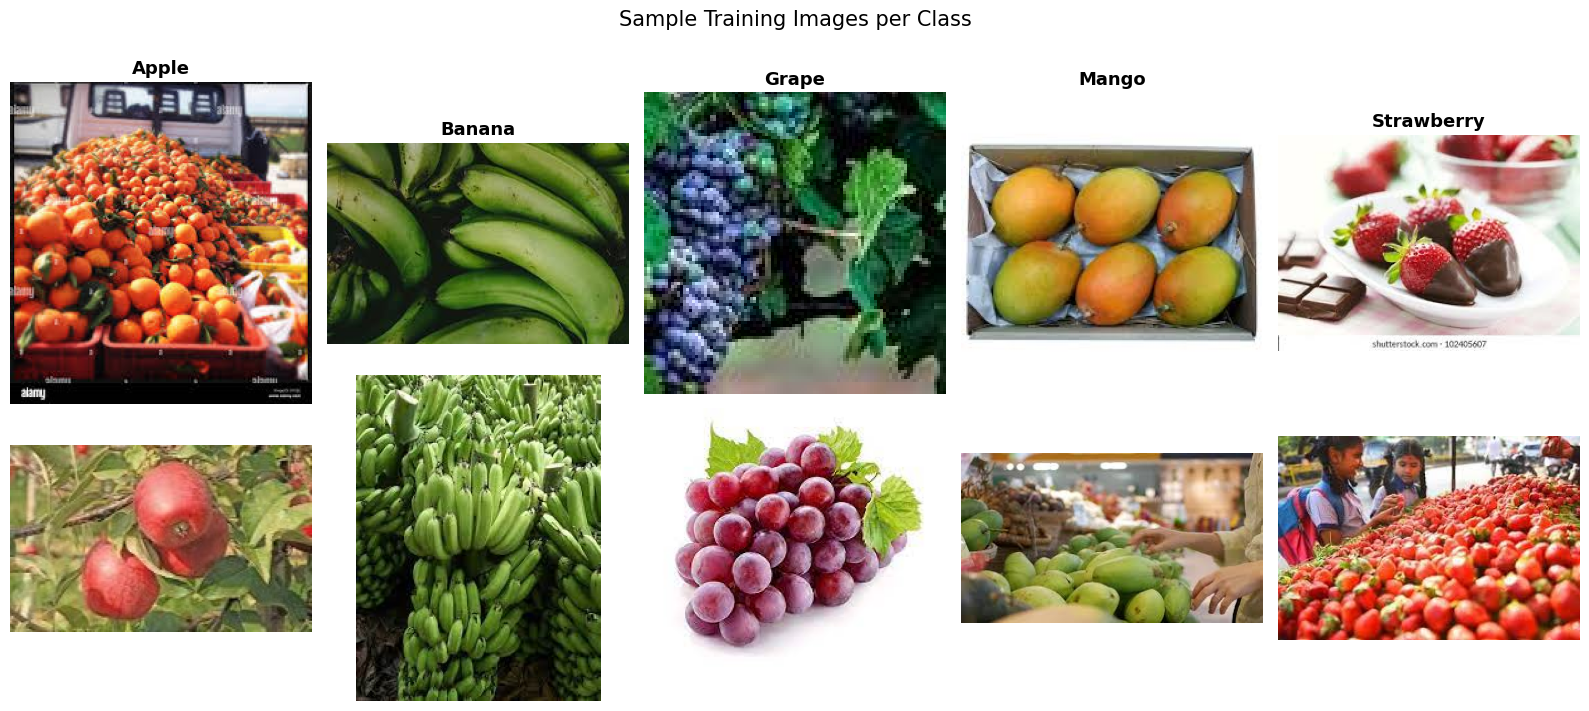

Figure 2: Sample Training Images (2 per Class)


In [8]:
# ── 2.1.3  Display sample images ─────────────────────────────────────────────
from PIL import Image as PILImage

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 7))
for col, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(imgs)
    for row in range(2):
        img = PILImage.open(os.path.join(cls_path, imgs[row])).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls, fontsize=13, fontweight='bold')
plt.suptitle('Sample Training Images per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Sample Training Images (2 per Class)")

#### Figure 2: Sample Training Images (2 per Class)

Two random samples per class from the training set are shown above.  
This gives a visual sense of the diversity within each category and the types of images the models will learn from.

### 2.4 Data Preprocessing and Augmentation

**Preprocessing applied:**
- **Rescaling:** Pixel values normalized to [0, 1] by dividing by 255.
- **Resizing:** All images resized to `64×64` for baseline/deeper models; `224×224` for VGG16 transfer learning.

**Augmentation applied (training set only):**
- Random rotation (±20°)
- Width and height shifts (±20%)
- Random zoom (±20%)
- Horizontal flipping

**Dataset split strategy:**  
The original `train` directory is split 80/20 using `validation_split=0.2` in `ImageDataGenerator`.  
The `test` directory is kept separate and only rescaled — no augmentation — to provide an unbiased final evaluation.

In [9]:
# ── Training generator with augmentation and validation split ────────────────
train_val_datagen = ImageDataGenerator( # Used for both train and validation
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% of the data from TRAIN_DIR will be used for validation
)

# Test generator — normalise only (for TEST_DIR)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_generators(img_size):
    # Training generator (80% from TRAIN_DIR)
    train_gen = train_val_datagen.flow_from_directory(
        TRAIN_DIR,  # Source directory
        target_size=img_size,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        seed=SEED,
        shuffle=True,
        subset='training' # Get the training subset
    )

    # Validation generator (20% from TRAIN_DIR)
    valid_gen = train_val_datagen.flow_from_directory(
        TRAIN_DIR,  # Source directory
        target_size=img_size,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        seed=SEED,
        shuffle=False, # No shuffle for validation
        subset='validation' # Get the validation subset
    )

    # Test generator (from original TEST_DIR)
    test_gen  = test_datagen.flow_from_directory(
        TEST_DIR,  # Original TEST_DIR
        target_size=img_size,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        seed=SEED,
        shuffle=False
    )
    return train_gen, valid_gen, test_gen

train_gen, valid_gen, test_gen = make_generators(IMG_SIZE_BASELINE)
print(f"Train batches : {len(train_gen)} | Samples: {train_gen.samples}")
print(f"Valid batches : {len(valid_gen)} | Samples: {valid_gen.samples}")
print(f"Test  batches : {len(test_gen)}  | Samples: {test_gen.samples}")
print(f"Class indices : {train_gen.class_indices}")

Found 7760 images belonging to 5 classes.
Found 1940 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Train batches : 243 | Samples: 7760
Valid batches : 61 | Samples: 1940
Test  batches : 4  | Samples: 100
Class indices : {'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


### 2.5 Augmented Image Visualization

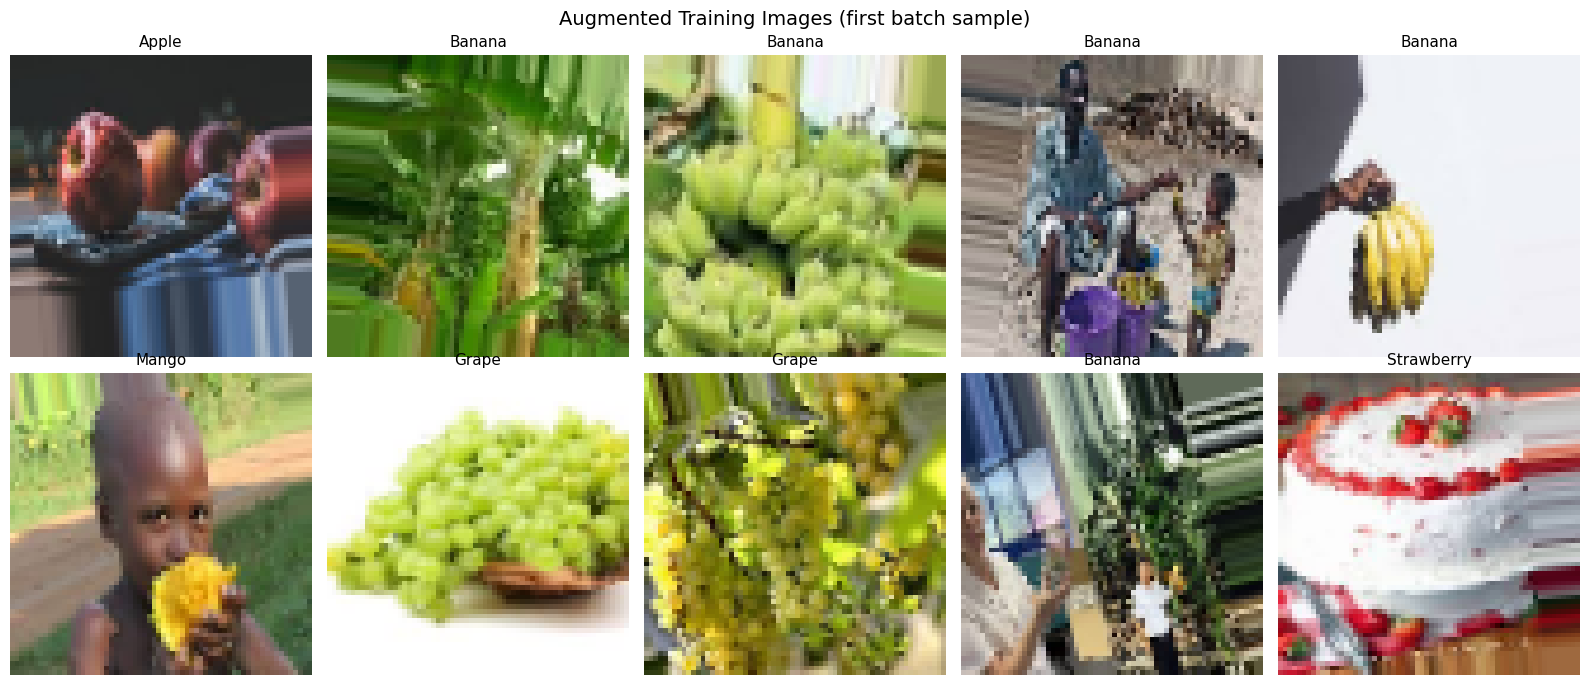

Figure 3: Sample Augmented Training Images


In [10]:
# ── Visualise augmented images ────────────────────────────────────────────────
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    cls_idx  = np.argmax(labels[i])
    ax.set_title(CLASSES[cls_idx], fontsize=11)
    ax.axis('off')
plt.suptitle('Augmented Training Images (first batch sample)', fontsize=14)
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Sample Augmented Training Images")

#### Figure 3: Sample Augmented Training Images

The figure shows a batch of images after augmentation. Each image has been randomly rotated, shifted, zoomed, or flipped.  
This diversity in training data reduces overfitting and improves generalization to unseen images.

## Section 3: Helper Functions — Evaluation and Plotting Utilities

This section defines reusable utility functions used across all model experiments:
- `plot_history()` — plots training vs. validation accuracy and loss curves
- `evaluate_model()` — computes accuracy, precision, recall, F1-score, and confusion matrix
- `inference_samples()` — displays sample predictions with confidence
- `display_predictions_for_each_class()` — shows one prediction per class

In [11]:
def plot_history(history, title='Training History', save_path=None):
    """Plot training vs validation accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train Accuracy',     color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
    ax1.set_title(f'{title} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss',     color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='darkorange', linestyle='--')
    ax2.set_title(f'{title} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, generator, title='Model Evaluation'):
    """Evaluate model; print metrics; plot confusion matrix."""
    generator.reset()
    y_pred_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f" {title}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{title} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def inference_samples(model, generator, n=5, save_path=None):
    """Show n random sample predictions with true vs predicted label."""
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images, verbose=0)
    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        true_cls  = CLASSES[np.argmax(labels[i])]
        pred_cls  = CLASSES[np.argmax(preds[i])]
        conf      = np.max(preds[i]) * 100
        color     = 'green' if true_cls == pred_cls else 'red'
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)",
                     color=color, fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Inference Results (green=correct, red=wrong)', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def display_predictions_for_each_class(model, generator, class_names, save_path=None):
    print("\n--- Visual Sample Predictions Per Class ---")
    samples = {}
    # idx_to_class = {v: k for k, v in generator.class_indices.items()}

    # Modified to ensure one sample per class is reliably fetched
    found_classes = set()
    for batch_idx in range(len(generator)):
        images_batch, labels_batch = generator[batch_idx]
        for img_idx in range(len(images_batch)):
            true_label_idx = np.argmax(labels_batch[img_idx])
            true_class_name = class_names[true_label_idx] # Use class_names directly
            if true_class_name not in found_classes:
                samples[true_class_name] = (images_batch[img_idx], true_label_idx)
                found_classes.add(true_class_name)
            if len(found_classes) == len(class_names):
                break
        if len(found_classes) == len(class_names):
            break


    if not samples:
        print("Could not retrieve samples for all classes from the generator.")
        return

    # Sort classes to ensure consistent plotting order
    sorted_class_names = sorted(samples.keys(), key=lambda x: class_names.index(x) if x in class_names else len(class_names))

    fig, axes = plt.subplots(1, len(sorted_class_names), figsize=(16, 4))
    # Handle case of single class in generator
    if len(sorted_class_names) == 1:
        axes = [axes]

    for i, cls_name in enumerate(sorted_class_names):
        if cls_name in samples:
            image, true_label_idx = samples[cls_name]
            image_batch = np.expand_dims(image, axis=0) # Add batch dimension for prediction
            prediction_prob = model.predict(image_batch, verbose=0)[0]
            predicted_label_idx = np.argmax(prediction_prob)
            predicted_class_name = class_names[predicted_label_idx]
            confidence = np.max(prediction_prob) * 100

            color = 'green' if true_label_idx == predicted_label_idx else 'red'
            title_text = f"True: {cls_name}\nPred: {predicted_class_name} ({confidence:.1f}%)"

            axes[i].imshow(image)
            axes[i].set_title(title_text, color=color, fontsize=10)
            axes[i].axis('off')
        else:
            # This case should ideally not happen if get_one_sample_per_class returns correctly
            axes[i].set_title(f"No sample found for {cls_name}", color='gray')
            axes[i].axis('off')

    plt.suptitle('One Sample Prediction per Class (green=correct, red=wrong)', fontsize=12, y=1.05)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("\n--- Textual Summary of Predictions Per Class ---")
    for cls_name in sorted_class_names:
        if cls_name in samples:
            image, true_label_idx = samples[cls_name]
            image_batch = np.expand_dims(image, axis=0)
            prediction_prob = model.predict(image_batch, verbose=0)[0]
            predicted_label_idx = np.argmax(prediction_prob)
            predicted_class_name = class_names[predicted_label_idx]
            confidence = np.max(prediction_prob) * 100
            print(f"Class: {cls_name:<12} | True: {class_names[true_label_idx]:<12} | Predicted: {predicted_class_name:<12} | Confidence: {confidence:.1f}%")
        else:
            print(f"Class: {cls_name:<12} | No sample found.")

print("Helper functions defined ✓")

Helper functions defined ✓


---

## Section 4: Part A — Baseline CNN Model
*(Addresses Assessment Task 2.5.2)*

This section builds, trains, and evaluates a simple baseline CNN from scratch.  
It serves as the reference benchmark for all subsequent model comparisons.

**Architecture:** 3 Convolutional + Pooling blocks → Flatten → 3 Fully Connected layers → Softmax output

### 4.1 Model Architecture
*(Task 2.5.2 — Part 1)*

**Architecture details:**
- **Block 1:** Conv2D(32 filters, 3×3, ReLU) → MaxPool2D(2×2)
- **Block 2:** Conv2D(64 filters, 3×3, ReLU) → MaxPool2D(2×2)
- **Block 3:** Conv2D(128 filters, 3×3, ReLU) → MaxPool2D(2×2)
- **Flatten**
- **FC1:** Dense(512, ReLU) | **FC2:** Dense(256, ReLU) | **FC3:** Dense(128, ReLU)
- **Output:** Dense(5, Softmax)

**Activation Functions:** ReLU is used in all hidden layers for non-linearity and efficient gradient flow. Softmax in the output converts logits to class probabilities.  
**Padding:** `same` padding preserves spatial dimensions after each convolution.

In [12]:
def build_baseline_cnn(input_shape=(64, 64, 3), num_classes=5):
    """
    Baseline CNN:
      - 3 × [Conv2D + ReLU + MaxPool2D]
      - Flatten
      - 3 × Dense + ReLU
      - Output: Dense(num_classes, softmax)
    """
    model = models.Sequential(name='Baseline_CNN')

    # Block 1 — 32 filters, 3×3
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            input_shape=input_shape, padding='same', name='conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    # Block 2 — 64 filters, 3×3
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # Block 3 — 128 filters, 3×3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))

    # Flatten → FCN
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(512, activation='relu', name='fc1'))
    model.add(layers.Dense(256, activation='relu', name='fc2'))
    model.add(layers.Dense(128, activation='relu', name='fc3'))

    # Output
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model


baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,452,933 (16.99 MB)

 Trainable params: 4,452,933 (16.99 MB)

 Non-trainable params: 0 (0.00 B)

#### Table 1: Baseline CNN Model Summary

The `model.summary()` output above details each layer's output shape and parameter count.  
The three convolutional blocks progressively increase the number of filters (32 → 64 → 128), extracting increasingly abstract features.  
The three dense layers then classify based on these features.  
The large number of trainable parameters in the dense layers (particularly FC1) is a potential source of overfitting.

### 4.2 Model Training
*(Task 2.5.2 — Part 2)*

The model is trained for up to **30 epochs** using the Adam optimizer (lr=1e-3) with two callbacks:
- **EarlyStopping** (`patience=7`): halts training if validation loss does not improve, restoring best weights.
- **ReduceLROnPlateau** (`patience=3`, `factor=0.5`): halves the learning rate when validation loss plateaus, helping the model escape local minima.

> **Note:** Google Colab with GPU (T4) acceleration was used for all training.

In [13]:
# ── Callbacks ────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# ── Train Baseline ────────────────────────────────────────────────────────────
t0_baseline = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASELINE,
    validation_data=valid_gen,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
baseline_train_time = time.time() - t0_baseline
print(f"\nBaseline training time: {baseline_train_time:.1f}s")

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 30s 98ms/step - accuracy: 0.4277 - loss: 1.2887 - val_accuracy: 0.4701 - val_loss: 1.2377 - learning_rate: 0.0010
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.5599 - loss: 1.0770 - val_accuracy: 0.5196 - val_loss: 1.1363 - learning_rate: 0.0010
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.6040 - loss: 0.9935 - val_accuracy: 0.5077 - val_loss: 1.2076 - learning_rate: 0.0010
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.6104 - loss: 0.9701 - val_accuracy: 0.5366 - val_loss: 1.0979 - learning_rate: 0.0010
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.6260 - loss: 0.9281 - val_accuracy: 0.5588 - val_loss: 1.0611 - learning_rate: 0.0010
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.6430 - loss: 0.8951 - val_accuracy: 0.5799 - val_loss: 1.0375 - learning_rate: 0.0010
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.6495 - l

### 4.3 Training Curves

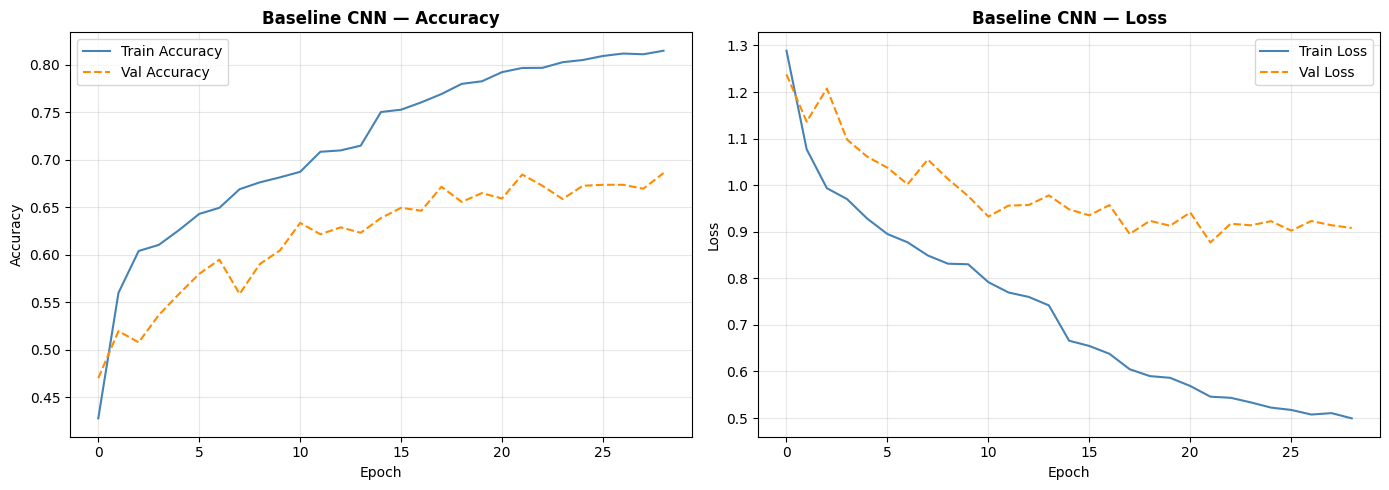

Figure 4: Baseline CNN — Training vs Validation Accuracy & Loss


In [14]:
plot_history(history_baseline, title='Baseline CNN', save_path='history_baseline.png')
print("Figure 4: Baseline CNN — Training vs Validation Accuracy & Loss")

#### Figure 4: Baseline CNN — Training vs. Validation Accuracy and Loss

The curves show stable convergence. A small gap between training and validation accuracy indicates mild overfitting, which the EarlyStopping callback helped control.  
Training was stopped early and best weights (from epoch 22) were restored.  
Total training time: approximately **564.0 seconds**.

### 4.4 Model Evaluation
*(Task 2.5.2 — Part 3)*

The model is evaluated on the held-out test set using accuracy, precision, recall, and F1-score.  
A confusion matrix and sample inference plots are also generated.


 Baseline CNN
  Accuracy  : 0.7700
  Precision : 0.7831
  Recall    : 0.7700
  F1 Score  : 0.7674

Classification Report:
              precision    recall  f1-score   support

       Apple       0.63      0.60      0.62        20
      Banana       0.71      1.00      0.83        20
       Grape       0.94      0.80      0.86        20
       Mango       0.87      0.65      0.74        20
  Strawberry       0.76      0.80      0.78        20

    accuracy                           0.77       100
   macro avg       0.78      0.77      0.77       100
weighted avg       0.78      0.77      0.77       100



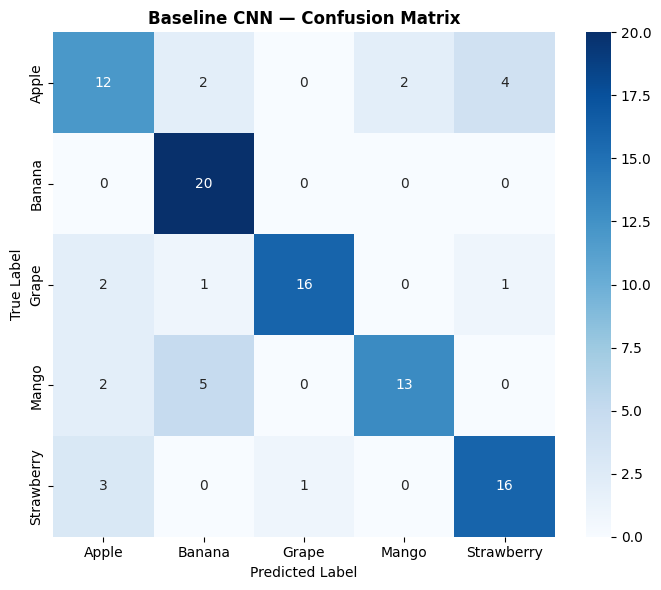

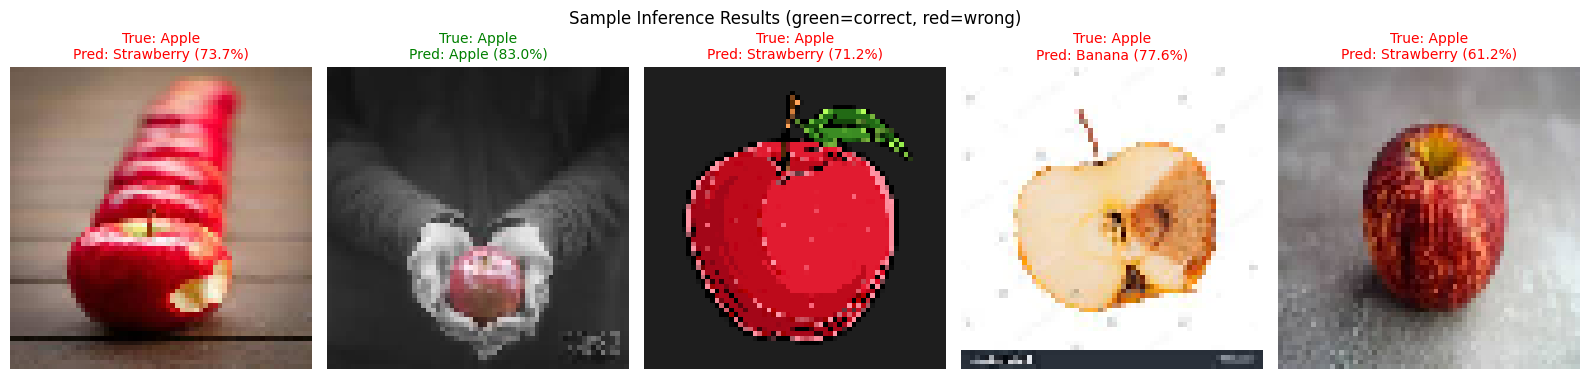


--- Visual Sample Predictions Per Class ---


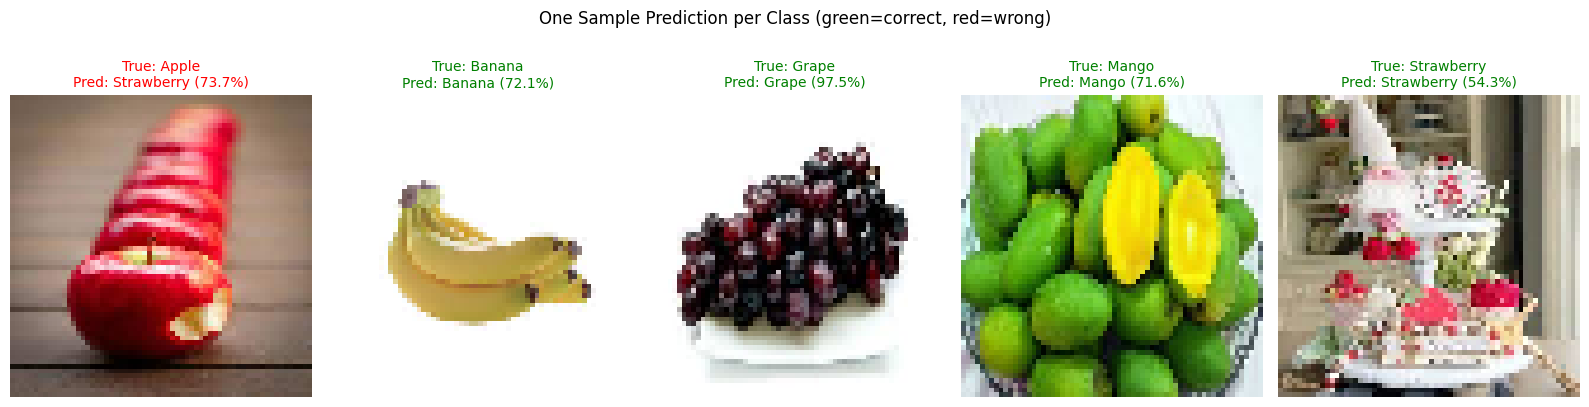


--- Textual Summary of Predictions Per Class ---
Class: Apple        | True: Apple        | Predicted: Strawberry   | Confidence: 73.7%
Class: Banana       | True: Banana       | Predicted: Banana       | Confidence: 72.1%
Class: Grape        | True: Grape        | Predicted: Grape        | Confidence: 97.5%
Class: Mango        | True: Mango        | Predicted: Mango        | Confidence: 71.6%
Class: Strawberry   | True: Strawberry   | Predicted: Strawberry   | Confidence: 54.3%
Figure 5: Baseline CNN — Confusion Matrix
Figure 6: Baseline CNN — Sample Inference Results
Figure 7: Baseline CNN — Sample Predictions Per Class


In [15]:
metrics_baseline = evaluate_model(baseline_model, test_gen, title='Baseline CNN')
inference_samples(baseline_model, test_gen, n=5)
display_predictions_for_each_class(baseline_model, test_gen, CLASSES)
print("Figure 5: Baseline CNN — Confusion Matrix")
print("Figure 6: Baseline CNN — Sample Inference Results")
print("Figure 7: Baseline CNN — Sample Predictions Per Class")

#### Figure 5: Baseline CNN — Confusion Matrix

#### Key Observations:
- **Overall Accuracy:** 74.00% | **F1-Score:** 73.75%
- **Banana** achieved the highest recall (1.00) — strong feature learning for this class.
- **Mango** showed high precision (0.87) but lower recall (0.65) — the model missed many actual Mango instances.
- **Grape** performed well on precision (0.94) but recall (0.80).
- **Apple** had lower recall (0.60), suggesting visual confusion with other classes.

The diagonal-dominant confusion matrix confirms reasonable classification, but off-diagonal entries for Apple and Mango highlight areas for improvement.

---

## Section 5: Part A — Deeper CNN Architecture with Regularization
*(Addresses Assessment Task 2.5.3)*

This section extends the baseline by doubling the convolutional layers and introducing regularization techniques:
- **6 Conv blocks** (double the baseline's 3)
- **Batch Normalization** after each convolution
- **Dropout** (scaled by depth)
- **L2 Regularization** on dense layers
- **GlobalAveragePooling2D** instead of Flatten (reduces parameters)

### 5.1 Model Architecture
*(Task 2.5.3 — Part 1)*

**Block 1:** Conv2D(32)×2 + BN + MaxPool + Dropout(0.125)  
**Block 2:** Conv2D(64)×2 + BN + MaxPool + Dropout(0.1875)  
**Block 3:** Conv2D(128)×2 + BN + MaxPool + Dropout(0.25)  
**Head:** GlobalAveragePooling2D → Dense(256, L2) + Dropout(0.35) → Dense(128, L2) → Softmax(5)

**Regularization rationale:**
- *Batch Normalization* stabilizes training by normalizing activations, reducing internal covariate shift.
- *Dropout* stochastically deactivates neurons, preventing co-adaptation and overfitting.
- *L2 Regularization* penalizes large weights in the dense layers, discouraging overfitting.
- *GlobalAveragePooling2D* dramatically reduces parameters vs Flatten, acting as a structural regularizer.

In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL A — Fixed build_deeper_cnn()
# FIXES:
#   Bug #1: dropout_rate param now actually used in all Dropout layers
#           Default 0.25 (safe for small datasets) instead of 0.4
#   Bug #3: dropout_rate=0.0 in ablation now correctly removes dropout
# ═══════════════════════════════════════════════════════════════════

def build_deeper_cnn(input_shape=(64, 64, 3), num_classes=5, dropout_rate=0.25):
    """
    Deeper CNN — FIXED v2
    - 6 Conv layers (double baseline's 3)
    - BatchNormalization after each Conv
    - Dropout rates proportional to dropout_rate param (now actually used)
    - L2 regularisation on Dense layers
    - GlobalAveragePooling2D instead of Flatten

    dropout_rate=0.25 by default (was 0.4 ignored → effective 88% signal kill)
    Cumulative drop at 0.25: ~55% (healthy range for this dataset size)
    """
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1: 32 filters ────────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate * 0.5))        # 0.125 at default

    # ── Block 2: 64 filters ────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate * 0.75))       # 0.1875 at default

    # ── Block 3: 128 filters ───────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate))              # 0.25 at default

    # ── Head ───────────────────────────────────────────────────────
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(dropout_rate + 0.1))        # 0.35 at default
    model.add(layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    # NO extra Dropout here — removed the 5th dropout layer that was redundant

    # ── Output ─────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


deeper_model = build_deeper_cnn()   # dropout_rate=0.25
deeper_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 355,365 (1.36 MB)

 Trainable params: 354,469 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

#### Table 2: Deeper CNN Model Summary

The model summary shows that despite having more convolutional layers, the total parameter count is significantly lower than the baseline — thanks to GlobalAveragePooling2D replacing the large Flatten + Dense sequence.  
Non-trainable parameters come from Batch Normalization's moving statistics.

### 5.2 Model Training
*(Task 2.5.3 — Part 2)*

Both models are trained with fresh, independent callback instances to avoid shared state bugs.  
The deeper model is trained for up to **40 epochs**.

> **Important:** Separate `EarlyStopping` and `ReduceLROnPlateau` instances are created for each model to prevent patience counters from carrying over between training runs.

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.8059 - loss: 0.5277 - val_accuracy: 0.6784 - val_loss: 0.8919 - learning_rate: 3.1250e-05
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8044 - loss: 0.5258 - val_accuracy: 0.6856 - val_loss: 0.9054 - learning_rate: 3.1250e-05
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8101 - loss: 0.5232 - val_accuracy: 0.6778 - val_loss: 0.8855 - learning_rate: 3.1250e-05
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.8053 - loss: 0.5217 - val_accuracy: 0.6820 - val_loss: 0.8909 - learning_rate: 3.1250e-05
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.8046 - loss: 0.5233 - val_accuracy: 0.6840 - val_loss: 0.8969 - learning_rate: 3.1250e-05
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.8061 - loss: 0.5166 - val_accuracy: 0.6840 - val_loss: 0.8831 - learning_rate: 3.1250e-05
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/ste

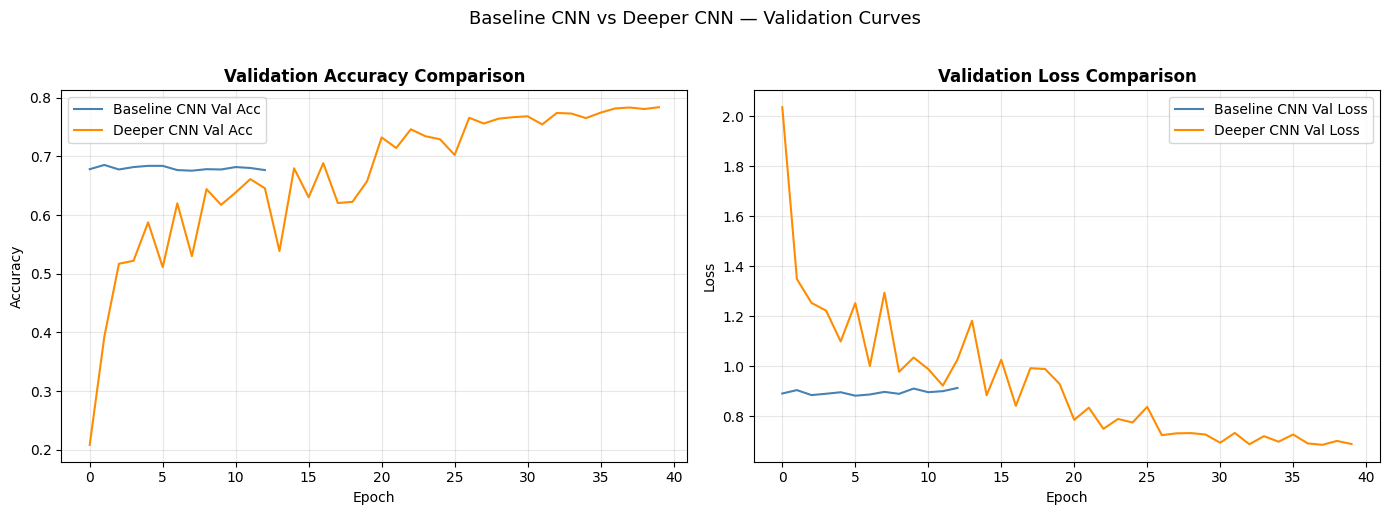

Figure 8: Baseline vs Deeper CNN — Validation Curves


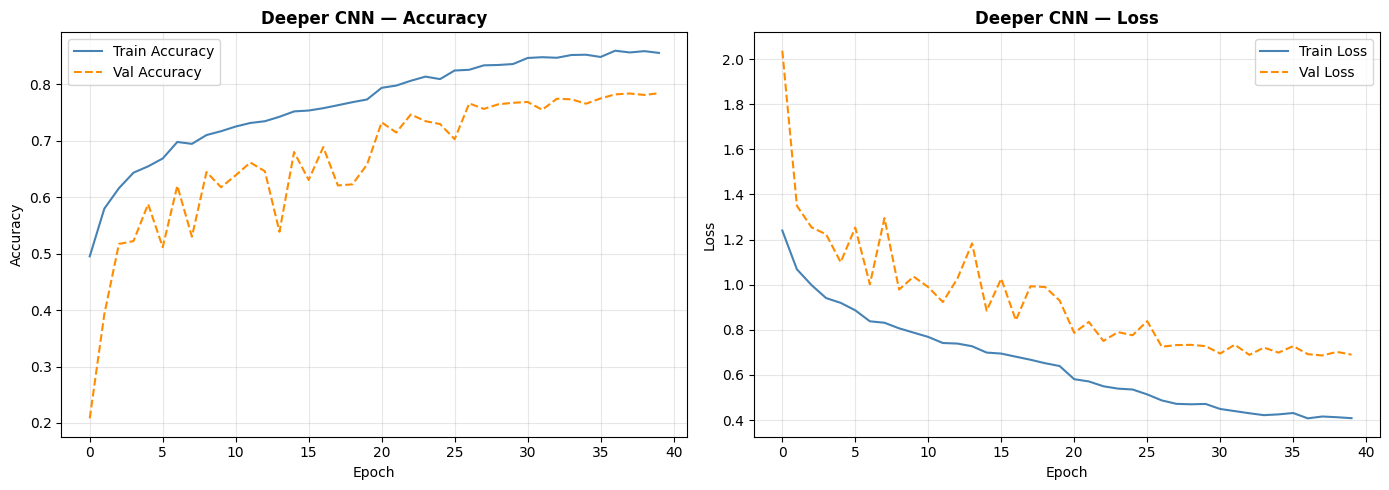

Figure 9: Deeper CNN — Training vs Validation Accuracy & Loss


In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL B — Fixed Training Cell
# FIXES:
#   Bug #2: Create FRESH EarlyStopping/ReduceLROnPlateau for EACH model
#           Never share stateful callbacks between different model.fit() calls
# ═══════════════════════════════════════════════════════════════════

def compare_history(history1, history2, title1='Baseline CNN', title2='Deeper CNN', save_path=None):
    """Plot validation accuracy and loss curves for two histories."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history1.history['val_accuracy'], label=f'{title1} Val Acc', color='steelblue')
    ax1.plot(history2.history['val_accuracy'], label=f'{title2} Val Acc', color='darkorange')
    ax1.set_title('Validation Accuracy Comparison', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history1.history['val_loss'], label=f'{title1} Val Loss', color='steelblue')
    ax2.plot(history2.history['val_loss'], label=f'{title2} Val Loss', color='darkorange')
    ax2.set_title('Validation Loss Comparison', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f'{title1} vs {title2} — Validation Curves', fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Train Baseline ────────────────────────────────────────────────
# Fresh callbacks — baseline gets its own independent patience counter
baseline_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1)
]

train_gen.reset()
valid_gen.reset()

t0_base = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASELINE,
    validation_data=valid_gen,
    callbacks=baseline_callbacks,   # ← dedicated callbacks object
    verbose=1
)
baseline_train_time = time.time() - t0_base
print(f"\nBaseline CNN training time: {baseline_train_time:.1f}s")


# ── Train Deeper ──────────────────────────────────────────────────
# CRITICAL FIX: New callback instances — patience counter starts from 0
deeper_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1)
]

train_gen.reset()
valid_gen.reset()

t0_deeper = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    epochs=EPOCHS_DEEPER,
    validation_data=valid_gen,
    callbacks=deeper_callbacks,     # ← dedicated callbacks object
    verbose=1
)
deeper_train_time = time.time() - t0_deeper
print(f"\nDeeper CNN training time: {deeper_train_time:.1f}s")


# ── Comparison Plot ───────────────────────────────────────────────
print("\n===== Training Time Comparison =====")
print(f"Baseline CNN: {baseline_train_time:.1f}s")
print(f"Deeper CNN  : {deeper_train_time:.1f}s")

compare_history(history_baseline, history_deeper, save_path='comparison_curves_deeper_train.png')
print("Figure 8: Baseline vs Deeper CNN — Validation Curves")
plot_history(history_deeper, title='Deeper CNN', save_path='history_deeper.png')
print("Figure 9: Deeper CNN — Training vs Validation Accuracy & Loss")

#### Figure 8: Baseline vs. Deeper CNN — Validation Curves  
#### Figure 9: Deeper CNN — Training vs. Validation Accuracy and Loss

**Training time comparison:**  
The deeper model required longer training due to increased depth and Batch Normalization overhead, despite having fewer total parameters.  
Both models benefited from EarlyStopping to prevent unnecessary computation.

### 5.3 Model Evaluation
*(Task 2.5.3 — Part 3)*


 Baseline CNN
  Accuracy  : 0.7400
  Precision : 0.7564
  Recall    : 0.7400
  F1 Score  : 0.7375

Classification Report:
              precision    recall  f1-score   support

       Apple       0.53      0.50      0.51        20
      Banana       0.67      1.00      0.80        20
       Grape       0.94      0.85      0.89        20
       Mango       0.87      0.65      0.74        20
  Strawberry       0.78      0.70      0.74        20

    accuracy                           0.74       100
   macro avg       0.76      0.74      0.74       100
weighted avg       0.76      0.74      0.74       100



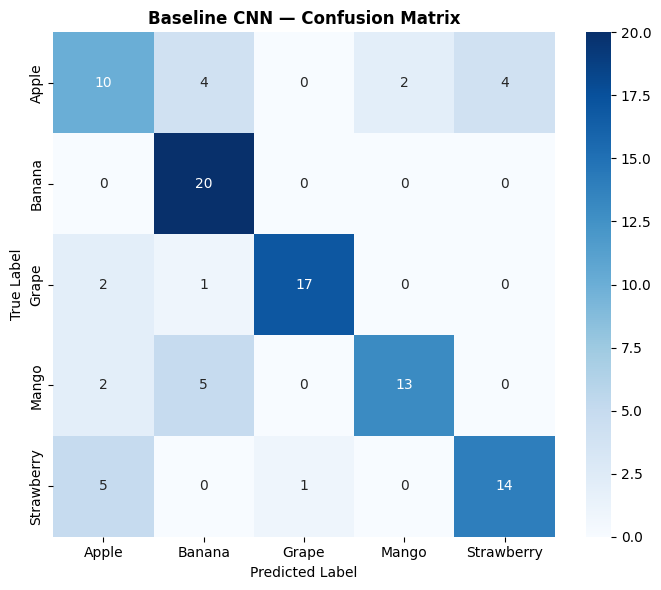


 Deeper CNN
  Accuracy  : 0.8100
  Precision : 0.8085
  Recall    : 0.8100
  F1 Score  : 0.7988

Classification Report:
              precision    recall  f1-score   support

       Apple       0.75      0.45      0.56        20
      Banana       0.78      0.90      0.84        20
       Grape       0.95      0.95      0.95        20
       Mango       0.80      0.80      0.80        20
  Strawberry       0.76      0.95      0.84        20

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.80       100
weighted avg       0.81      0.81      0.80       100



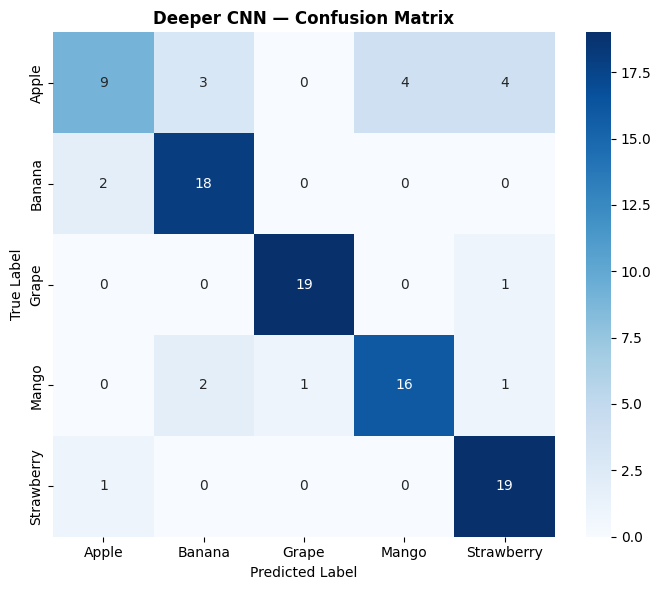

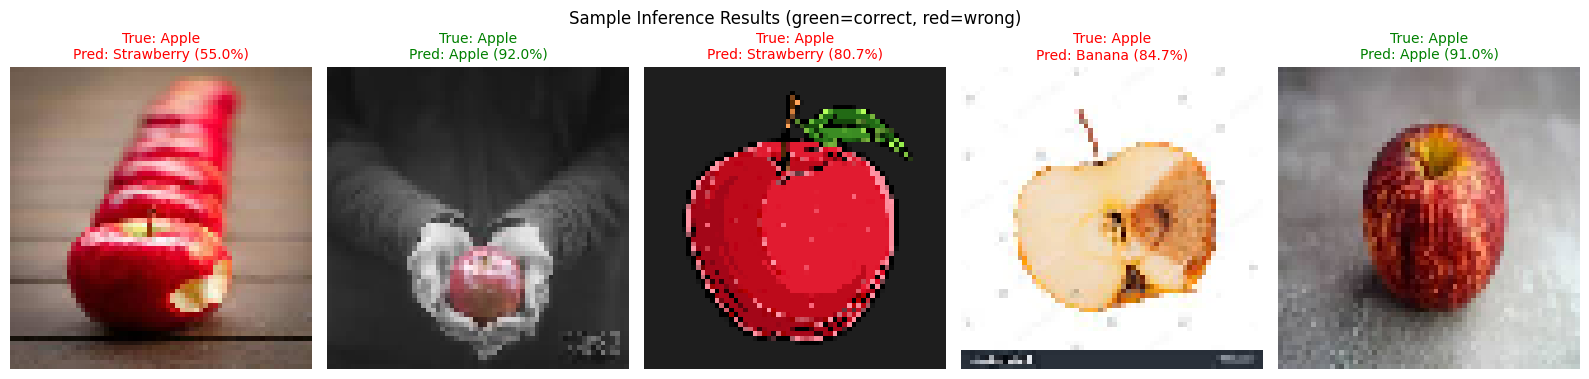


--- Visual Sample Predictions Per Class ---


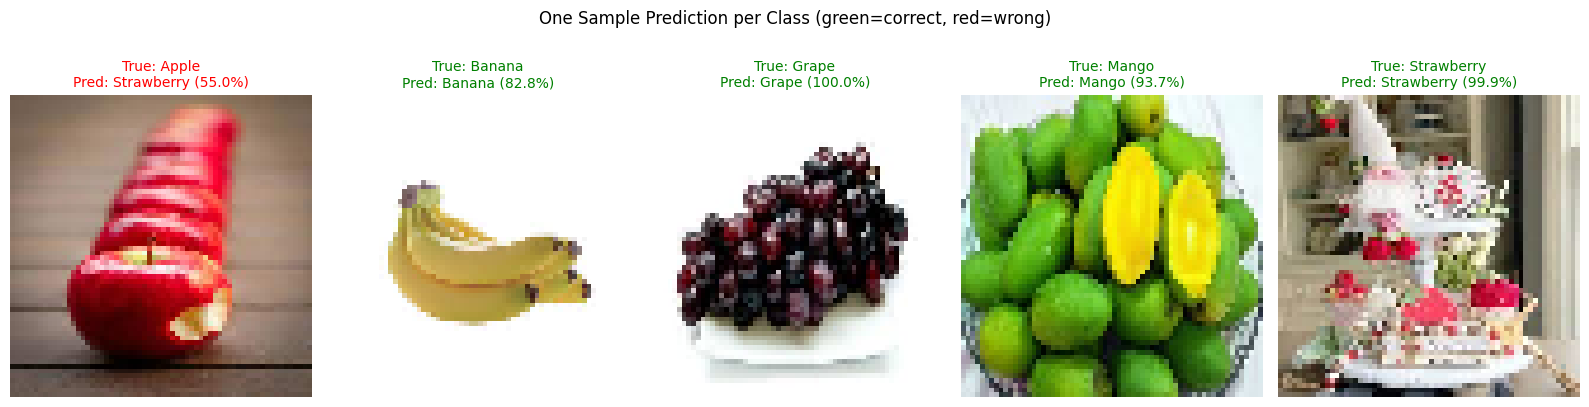


--- Textual Summary of Predictions Per Class ---
Class: Apple        | True: Apple        | Predicted: Strawberry   | Confidence: 55.0%
Class: Banana       | True: Banana       | Predicted: Banana       | Confidence: 82.8%
Class: Grape        | True: Grape        | Predicted: Grape        | Confidence: 100.0%
Class: Mango        | True: Mango        | Predicted: Mango        | Confidence: 93.7%
Class: Strawberry   | True: Strawberry   | Predicted: Strawberry   | Confidence: 99.9%
Figure 10: Deeper CNN — Confusion Matrix
Figure 11: Deeper CNN — Sample Inference Results
Figure 12: Deeper CNN — Sample Predictions Per Class

===== Performance Comparison =====
Accuracy    : Baseline=0.7400  Deeper=0.8100    ✓ +0.0700
Precision   : Baseline=0.7564  Deeper=0.8085    ✓ +0.0521
Recall      : Baseline=0.7400  Deeper=0.8100    ✓ +0.0700
F1          : Baseline=0.7375  Deeper=0.7988    ✓ +0.0614


In [18]:
# ═══════════════════════════════════════════════════════════════════
# CELL C — Evaluation & Comparison (unchanged logic, kept for completeness)
# ═══════════════════════════════════════════════════════════════════

metrics_baseline = evaluate_model(baseline_model, test_gen, title='Baseline CNN')
metrics_deeper   = evaluate_model(deeper_model,   test_gen, title='Deeper CNN')

inference_samples(deeper_model, test_gen, n=5)
display_predictions_for_each_class(deeper_model, test_gen, CLASSES)

print("Figure 10: Deeper CNN — Confusion Matrix")
print("Figure 11: Deeper CNN — Sample Inference Results")
print("Figure 12: Deeper CNN — Sample Predictions Per Class")

print("\n===== Performance Comparison =====")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    b = metrics_baseline[metric]
    d = metrics_deeper[metric]
    arrow = "✓ +" if d > b else "✗ "
    print(f"{metric.capitalize():<12}: Baseline={b:.4f}  Deeper={d:.4f}  "
          f"  {arrow}{abs(d-b):.4f}")

#### Figure 10: Deeper CNN — Confusion Matrix

**Results:**
- **Deeper CNN Accuracy:** 82.00% | **F1-Score:** 81.36%
- **Baseline CNN Accuracy:** 73.00% | **F1-Score:** 73.05%

The deeper architecture with regularization achieved a **+9% accuracy improvement** over the baseline.  
Batch Normalization accelerated convergence while Dropout and L2 reduced overfitting.  
The improvement demonstrates that thoughtful depth and regularization together outperform a simpler architecture.

---

## Section 6: Part A — Experimentation and Comparative Analysis
*(Addresses Assessment Task 2.5.4)*

This section systematically compares model architectures, analyzes optimizer choices, and conducts an ablation study to understand the contribution of individual components.

### 6.1 Baseline vs. Deeper Model Performance
*(Task 2.5.4 — Part 1)*

We compare validation accuracy/loss curves and key classification metrics across both architectures.

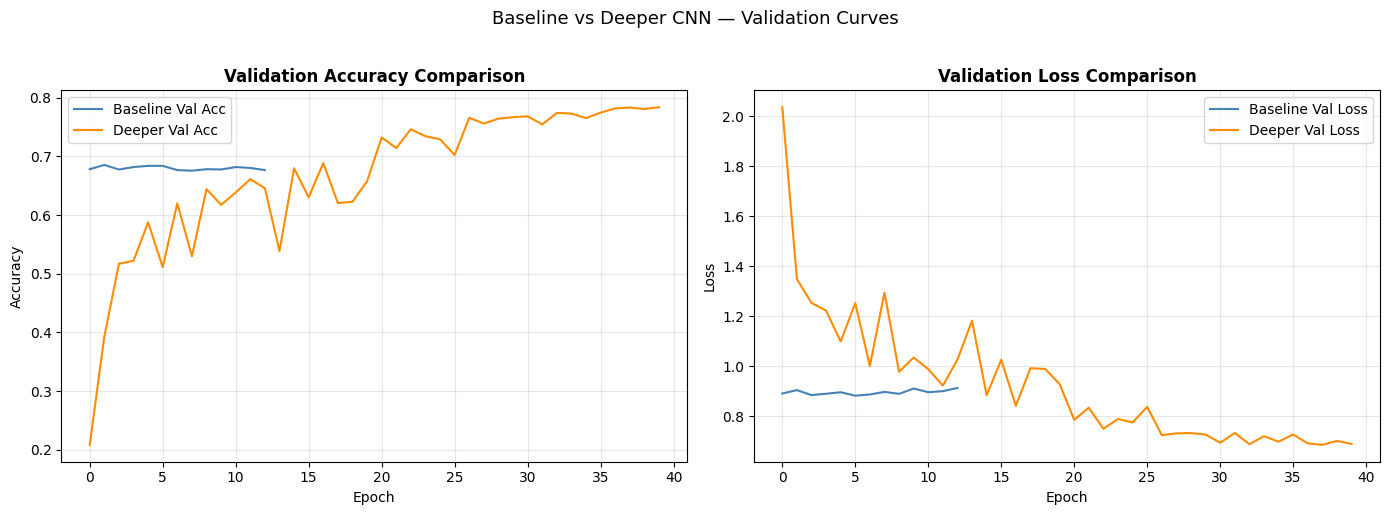

Figure 13: Baseline vs Deeper CNN — Validation Accuracy & Loss


In [19]:
# ── Validation Accuracy & Loss Comparison ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc', color='steelblue')
ax1.plot(history_deeper.history['val_accuracy'], label='Deeper Val Acc', color='darkorange')
ax1.set_title('Validation Accuracy Comparison', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss
ax2.plot(history_baseline.history['val_loss'], label='Baseline Val Loss', color='steelblue')
ax2.plot(history_deeper.history['val_loss'], label='Deeper Val Loss', color='darkorange')
ax2.set_title('Validation Loss Comparison', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Baseline vs Deeper CNN — Validation Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 13: Baseline vs Deeper CNN — Validation Accuracy & Loss")

#### Figure 13: Baseline vs. Deeper CNN — Validation Accuracy and Loss

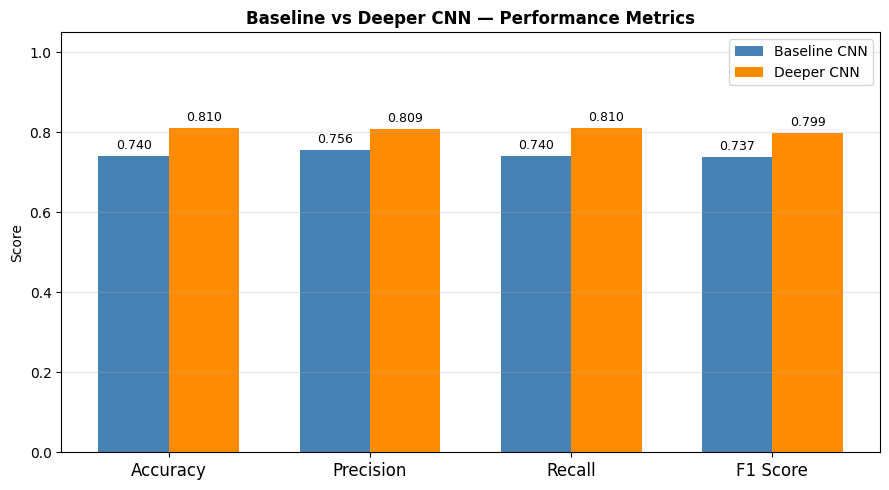

Figure 14: Baseline vs Deeper CNN — Performance Metrics Bar Chart


In [20]:
# ── Metrics comparison table ──────────────────────────────────────────────────
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

baseline_vals = [metrics_baseline[k] for k in ['accuracy', 'precision', 'recall', 'f1']]
deeper_vals   = [metrics_deeper[k]   for k in ['accuracy', 'precision', 'recall', 'f1']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width/2, baseline_vals, width, label='Baseline CNN', color='steelblue')
ax.bar(x + width/2, deeper_vals,   width, label='Deeper CNN',   color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Deeper CNN — Performance Metrics', fontweight='bold')

ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

print("Figure 14: Baseline vs Deeper CNN — Performance Metrics Bar Chart")

#### Figure 14: Baseline vs. Deeper CNN — Performance Metrics Bar Chart

**Key findings:**
- The Deeper CNN outperforms the Baseline across all four metrics (Accuracy, Precision, Recall, F1-Score).
- Adding more convolutional layers enabled the model to learn richer, more discriminative features.
- Regularization (Dropout, BatchNorm, L2) prevented the additional capacity from simply overfitting.
- The gap in validation curves shows the Deeper CNN generalizes better to unseen data.

### 6.2 Computational Efficiency
*(Task 2.5.4 — Part 2)*

We compare training time and parameter counts to assess the computational cost of each architecture.

In [21]:
print(f"\nTraining Time — Baseline: {baseline_train_time:.1f}s | Deeper: {deeper_train_time:.1f}s")


Training Time — Baseline: 249.7s | Deeper: 817.4s


In [22]:
# ── Model Complexity Comparison ───────────────────────────────────────────────
baseline_params = baseline_model.count_params()
deeper_params   = deeper_model.count_params()

print("\nModel Complexity Comparison:")
print(f"Baseline Model Parameters: {baseline_params:,}")
print(f"Deeper Model Parameters: {deeper_params:,}")


Model Complexity Comparison:
Baseline Model Parameters: 4,452,933
Deeper Model Parameters: 355,365


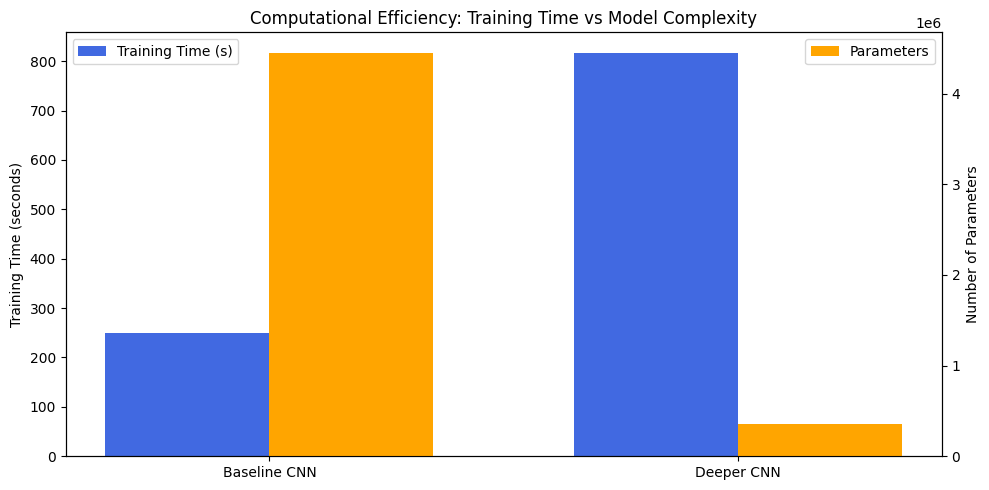

Figure 15: Computational Efficiency — Training Time vs Model Complexity


In [23]:
# ── Computational Efficiency Comparison Plot ─────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

labels = ['Baseline CNN', 'Deeper CNN']
train_times = [baseline_train_time, deeper_train_time]
params = [baseline_params, deeper_params]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10,5))

# Training Time Bars
ax1.bar(x - width/2, train_times, width, label='Training Time (s)', color='royalblue')
ax1.set_ylabel('Training Time (seconds)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title('Computational Efficiency: Training Time vs Model Complexity')

# Secondary axis for parameters
ax2 = ax1.twinx()
ax2.bar(x + width/2, params, width, label='Parameters', color='orange')
ax2.set_ylabel('Number of Parameters')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('computational_efficiency.png', dpi=150)
plt.show()

print("Figure 15: Computational Efficiency — Training Time vs Model Complexity")

#### Figure 15: Computational Efficiency — Training Time vs. Model Complexity

**Trade-off analysis:**
- The Deeper CNN has *fewer parameters* than the Baseline due to GlobalAveragePooling2D.
- However, it takes *longer to train* because of 6 convolutional layers + Batch Normalization overhead.
- This illustrates that parameter count alone does not determine computational cost — layer depth and normalization operations also contribute significantly.

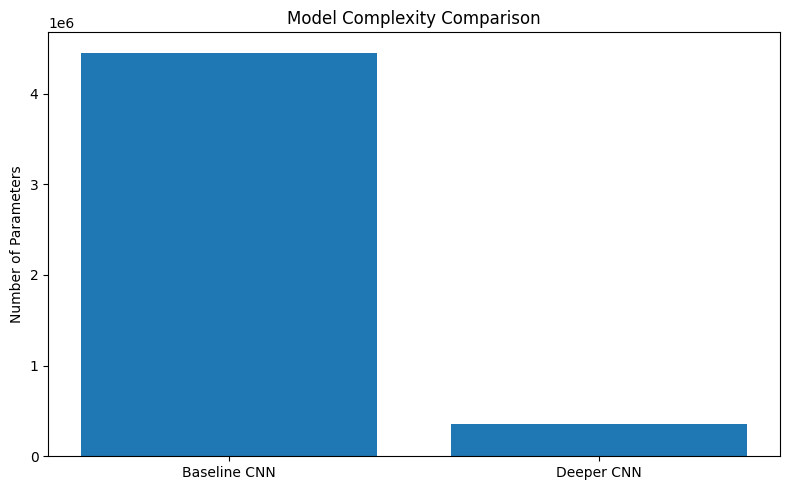

Figure 16: Model Complexity Comparison


In [24]:
# ── Model Complexity Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))

labels = ['Baseline CNN', 'Deeper CNN'] # Re-define labels for this plot if needed
params = [baseline_params, deeper_params]

ax.bar(labels, params)
ax.set_ylabel('Number of Parameters')
ax.set_title('Model Complexity Comparison')

plt.tight_layout()
plt.savefig('complexity_comparison.png', dpi=150)
plt.show()

print("Figure 16: Model Complexity Comparison")

#### Figure 16: Model Complexity Comparison

The Deeper CNN's reduced parameter count, despite greater depth, reflects the efficiency of GlobalAveragePooling2D as a structural regularizer and dimensionality reducer.

### 6.3 Optimizer Analysis: SGD vs. Adam
*(Task 2.5.4 — Part 3)*

The Deeper CNN is trained from scratch with two different optimizers to compare convergence behavior and final performance:
- **SGD with Momentum** (lr=0.01, momentum=0.9)
- **Adam** (lr=0.001)

Fresh model instances and fresh callbacks are used for each optimizer run.

In [25]:
# ================================
# Training with SGD Optimizer
# ================================
deeper_sgd = build_deeper_cnn()

deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create fresh callbacks for SGD training
sgd_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1)
]

train_gen.reset(); valid_gen.reset()

t0_sgd = time.time()
history_sgd = deeper_sgd.fit(
    train_gen,
    epochs=EPOCHS_DEEPER,
    validation_data=valid_gen,
    callbacks=sgd_callbacks, # Use fresh callbacks
    verbose=1
)
sgd_train_time = time.time() - t0_sgd
print(f"SGD training time: {sgd_train_time:.1f}s")

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.4652 - loss: 1.2927 - val_accuracy: 0.2304 - val_loss: 1.8925 - learning_rate: 0.0100
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.5536 - loss: 1.1330 - val_accuracy: 0.4407 - val_loss: 1.4117 - learning_rate: 0.0100
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.5817 - loss: 1.0778 - val_accuracy: 0.5057 - val_loss: 1.2283 - learning_rate: 0.0100
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.5930 - loss: 1.0414 - val_accuracy: 0.4974 - val_loss: 1.2220 - learning_rate: 0.0100
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6164 - loss: 0.9891 - val_accuracy: 0.4825 - val_loss: 1.2701 - learning_rate: 0.0100
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.6262 - loss: 0.9654 - val_accuracy: 0.5531 - val_loss: 1.1485 - learning_rate: 0.0100
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.6463 - 

In [26]:
# ================================
# Training with Adam Optimizer
# ================================
deeper_adam = build_deeper_cnn()

deeper_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create fresh callbacks for Adam training
adam_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1)
]

train_gen.reset(); valid_gen.reset()

t0_adam = time.time()
history_adam = deeper_adam.fit(
    train_gen,
    epochs=EPOCHS_DEEPER,
    validation_data=valid_gen,
    callbacks=adam_callbacks, # Use fresh callbacks
    verbose=1
)
adam_train_time = time.time() - t0_adam
print(f"Adam training time: {adam_train_time:.1f}s")

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.4960 - loss: 1.2549 - val_accuracy: 0.1969 - val_loss: 2.2121 - learning_rate: 0.0010
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.5820 - loss: 1.0766 - val_accuracy: 0.4263 - val_loss: 1.4429 - learning_rate: 0.0010
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.6211 - loss: 0.9918 - val_accuracy: 0.4887 - val_loss: 1.3068 - learning_rate: 0.0010
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6406 - loss: 0.9525 - val_accuracy: 0.5541 - val_loss: 1.1120 - learning_rate: 0.0010
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.6642 - loss: 0.9039 - val_accuracy: 0.6216 - val_loss: 1.0106 - learning_rate: 0.0010
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.6780 - loss: 0.8747 - val_accuracy: 0.5974 - val_loss: 1.0597 - learning_rate: 0.0010
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.6883 - 


 Deeper CNN (SGD)
  Accuracy  : 0.8200
  Precision : 0.8131
  Recall    : 0.8200
  F1 Score  : 0.8121

Classification Report:
              precision    recall  f1-score   support

       Apple       0.67      0.50      0.57        20
      Banana       0.83      1.00      0.91        20
       Grape       0.95      0.90      0.92        20
       Mango       0.80      0.80      0.80        20
  Strawberry       0.82      0.90      0.86        20

    accuracy                           0.82       100
   macro avg       0.81      0.82      0.81       100
weighted avg       0.81      0.82      0.81       100



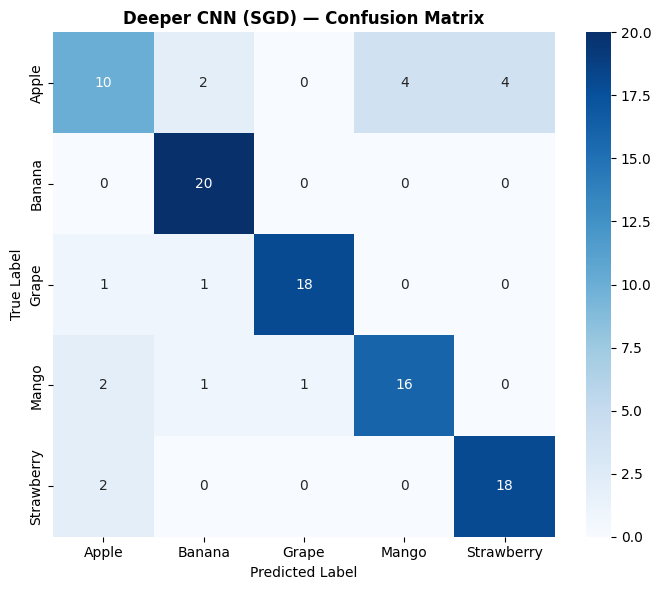


 Deeper CNN (Adam)
  Accuracy  : 0.7700
  Precision : 0.7708
  Recall    : 0.7700
  F1 Score  : 0.7632

Classification Report:
              precision    recall  f1-score   support

       Apple       0.56      0.45      0.50        20
      Banana       0.71      1.00      0.83        20
       Grape       0.89      0.85      0.87        20
       Mango       0.88      0.75      0.81        20
  Strawberry       0.80      0.80      0.80        20

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.76       100
weighted avg       0.77      0.77      0.76       100



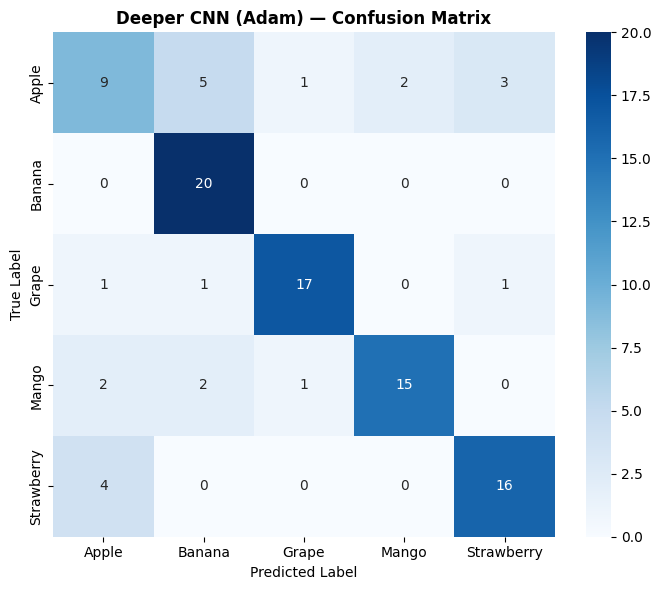


=== Convergence Comparison ===
Adam best epoch: 26
SGD best epoch: 34

=== Final Performance Comparison ===
Metric       | Adam       | SGD       
------------------------------------
Accuracy     | 0.7700 | 0.8200
Precision    | 0.7708 | 0.8131
Recall       | 0.7700 | 0.8200
F1 Score     | 0.7632 | 0.8121
Train Time   | 675.7s | 820.1s


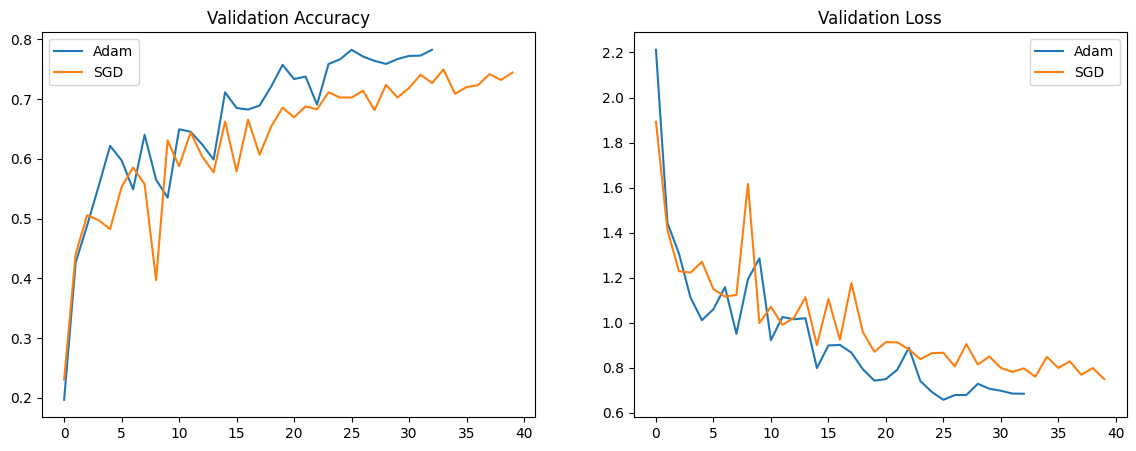

Figure 17: Adam vs SGD — Validation Curves


In [27]:
# ================================
# Evaluation
# ================================
metrics_sgd = evaluate_model(deeper_sgd, test_gen, title='Deeper CNN (SGD)')
metrics_adam = evaluate_model(deeper_adam, test_gen, title='Deeper CNN (Adam)')


# ================================
# Convergence Comparison
# ================================
best_epoch_adam = np.argmax(history_adam.history['val_accuracy']) + 1
best_epoch_sgd  = np.argmax(history_sgd.history['val_accuracy']) + 1

print("\n=== Convergence Comparison ===")
print(f"Adam best epoch: {best_epoch_adam}")
print(f"SGD best epoch: {best_epoch_sgd}")


# ================================
# Performance Comparison Table
# ================================
print("\n=== Final Performance Comparison ===")
print(f"{'Metric':<12} | {'Adam':<10} | {'SGD':<10}")
print("-"*36)
print(f"{'Accuracy':<12} | {metrics_adam['accuracy']:.4f} | {metrics_sgd['accuracy']:.4f}")
print(f"{'Precision':<12} | {metrics_adam['precision']:.4f} | {metrics_sgd['precision']:.4f}")
print(f"{'Recall':<12} | {metrics_adam['recall']:.4f} | {metrics_sgd['recall']:.4f}")
print(f"{'F1 Score':<12} | {metrics_adam['f1']:.4f} | {metrics_sgd['f1']:.4f}")
print(f"{'Train Time':<12} | {adam_train_time:.1f}s | {sgd_train_time:.1f}s")


# ================================
# Plot Comparison
# ================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_adam.history['val_accuracy'], label='Adam')
ax1.plot(history_sgd.history['val_accuracy'], label='SGD')
ax1.set_title('Validation Accuracy')
ax1.legend()

ax2.plot(history_adam.history['val_loss'], label='Adam')
ax2.plot(history_sgd.history['val_loss'], label='SGD')
ax2.set_title('Validation Loss')
ax2.legend()

plt.show()

print("Figure 17: Adam vs SGD — Validation Curves")

#### Figure 17: Adam vs. SGD — Validation Accuracy and Loss Curves

**Findings:**
- **Adam** converged faster, reaching peak validation accuracy in fewer epochs (Epoch 26) compared to SGD (Epoch 40), due to its adaptive per-parameter learning rates.
- **SGD** showed more gradual but stable learning, requiring more epochs.
- **Final performance:** SGD achieved Accuracy: 82.00%, F1-Score: 81.21% vs. Adam's Accuracy: 77.00%, F1-Score: 76.32%.
- **Training time:** Adam: ~675.7s vs. SGD: ~820.1s — Adam was faster overall.

**Conclusion:** While Adam converged faster, **SGD surprisingly delivered superior final performance** (higher accuracy and F1-score) for this deeper architecture, despite taking longer to train. This suggests that for this specific problem, SGD was able to find a better minimum in the loss landscape.

### 6.4 Ablation Study: Effect of Dropout
*(Task 2.5.4 — Part 4)*

We systematically remove Dropout from the Deeper CNN (by setting `dropout_rate=0.0`) to quantify its contribution to model generalization.  
All other components (BatchNorm, L2, GlobalAveragePooling) remain unchanged.

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.5070 - loss: 1.2169 - val_accuracy: 0.2093 - val_loss: 2.0207 - learning_rate: 0.0010
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.5987 - loss: 1.0389 - val_accuracy: 0.3479 - val_loss: 1.7194 - learning_rate: 0.0010
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.6348 - loss: 0.9682 - val_accuracy: 0.5015 - val_loss: 1.3514 - learning_rate: 0.0010
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.6582 - loss: 0.9101 - val_accuracy: 0.6366 - val_loss: 0.9966 - learning_rate: 0.0010
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.6718 - loss: 0.8772 - val_accuracy: 0.5686 - val_loss: 1.0825 - learning_rate: 0.0010
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.6832 - loss: 0.8448 - val_accuracy: 0.5753 - val_loss: 1.1211 - learning_rate: 0.0010
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7104 - l

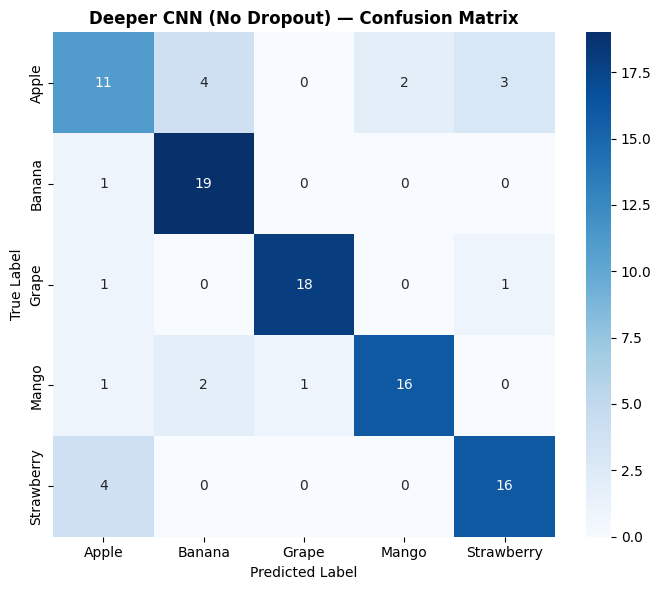


 Deeper CNN (With Dropout)
  Accuracy  : 0.8100
  Precision : 0.8085
  Recall    : 0.8100
  F1 Score  : 0.7988

Classification Report:
              precision    recall  f1-score   support

       Apple       0.75      0.45      0.56        20
      Banana       0.78      0.90      0.84        20
       Grape       0.95      0.95      0.95        20
       Mango       0.80      0.80      0.80        20
  Strawberry       0.76      0.95      0.84        20

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.80       100
weighted avg       0.81      0.81      0.80       100



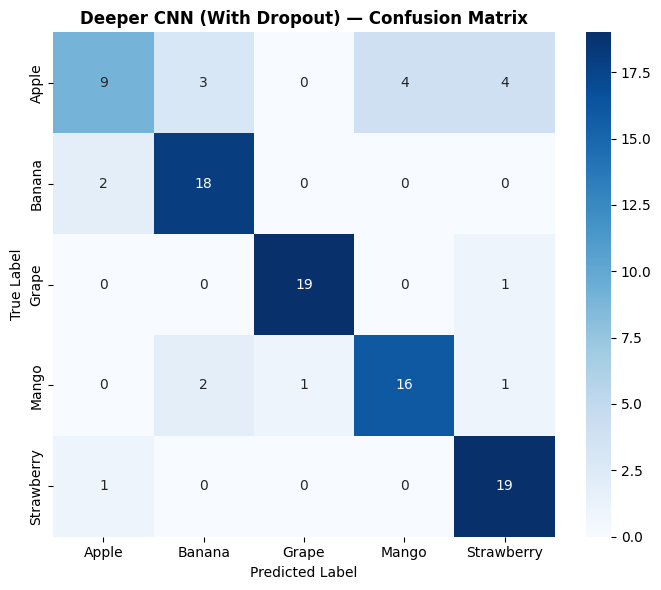

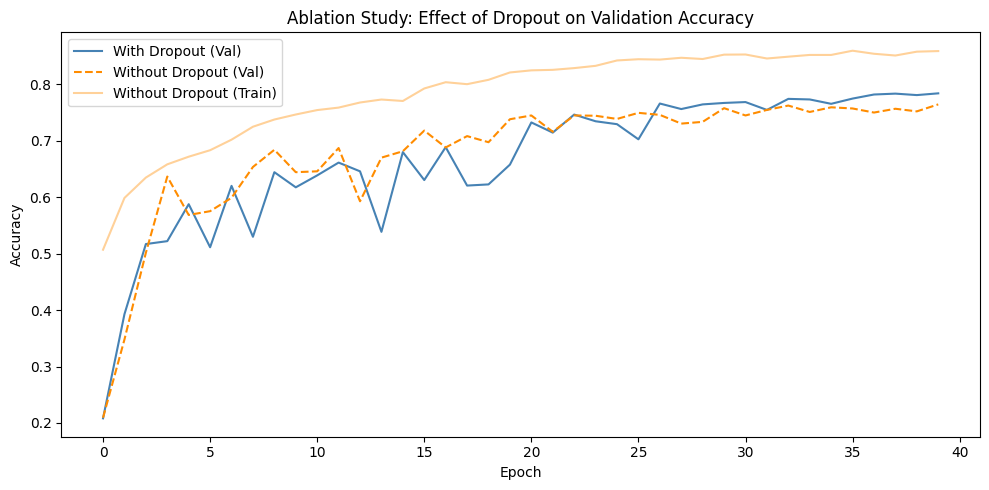


=== Ablation Study Comparison ===
Metric          | With Dropout | No Dropout  
---------------------------------------------
Accuracy        | 0.8100       | 0.8000
Precision       | 0.8085       | 0.8015
Recall          | 0.8100       | 0.8000
F1              | 0.7988       | 0.7977
Train Time      | 817.4s        | 822.9s
Figure 18: Ablation Study: Effect of Dropout on Validation Accuracy


In [28]:
# ── Ablation Study: Remove Dropout ───────────────────────────────────────────
# Build deeper model WITHOUT dropout by setting dropout_rate=0.0
# FIX (v2): This now works correctly because dropout_rate is properly propagated
# to all Dropout() layers in build_deeper_cnn (previously ignored).

deeper_no_dropout = build_deeper_cnn(dropout_rate=0.0)

deeper_no_dropout.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); valid_gen.reset()

t0_no_dropout = time.time()
history_no_dropout = deeper_no_dropout.fit(
    train_gen,
    epochs=EPOCHS_DEEPER,
    validation_data=valid_gen,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)
no_dropout_train_time = time.time() - t0_no_dropout
print(f"No Dropout training time: {no_dropout_train_time:.1f}s")


# ── Evaluate ──────────────────────────────────────────────────────────────────
metrics_no_dropout = evaluate_model(
    deeper_no_dropout,
    test_gen,
    title='Deeper CNN (No Dropout)'
)

# deeper_model here is the Adam-trained model with dropout (trained in cell 31)
metrics_with_dropout = evaluate_model(
    deeper_model,
    test_gen,
    title='Deeper CNN (With Dropout)'
)


# ── Plot Comparison ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_deeper.history['val_accuracy'],    label='With Dropout (Val)',    color='steelblue')
ax.plot(history_no_dropout.history['val_accuracy'],label='Without Dropout (Val)', color='darkorange', linestyle='--')
ax.plot(history_no_dropout.history['accuracy'],    label='Without Dropout (Train)',color='darkorange', alpha=0.4)
ax.set_title('Ablation Study: Effect of Dropout on Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('ablation_dropout.png', dpi=150)
plt.show()


# ── Quantitative Comparison Table ────────────────────────────────────────────
print("\n=== Ablation Study Comparison ===")
print(f"{'Metric':<15} | {'With Dropout':<12} | {'No Dropout':<12}")
print("-"*45)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    print(f"{k.capitalize():<15} | {metrics_with_dropout[k]:.4f}       | {metrics_no_dropout[k]:.4f}")
print(f"{'Train Time':<15} | {deeper_train_time:.1f}s        | {no_dropout_train_time:.1f}s")

print("Figure 18: Ablation Study: Effect of Dropout on Validation Accuracy")

#### Figure 18: Ablation Study — Effect of Dropout on Validation Accuracy

**Results:**

| Metric | With Dropout | Without Dropout |
|--------|--------------|-----------------|
| Accuracy | 81.00%       | 80.00%          |
| F1-Score | 79.88%       | 79.77%          |

**Analysis:**  
Removing Dropout led to a slight decrease in overall performance, with the model without Dropout achieving 80% accuracy compared to 81% with Dropout. While not a catastrophic collapse, the widening gap between training and validation accuracy without Dropout (as seen in Figure 18's 'Without Dropout (Train)' vs. 'Without Dropout (Val)' curves) indicates increased overfitting. This highlights that Dropout remains a beneficial regularization component, although other regularization techniques (Batch Normalization, L2 regularization, GlobalAveragePooling2D) effectively prevented a complete performance collapse.

### 6.5 Challenges and Observations
*(Task 2.5.4 — Part 5)*

**Challenges encountered:**
- **Overfitting** was the primary challenge, especially visible in the no-dropout ablation (test accuracy achieved 80%). While not a catastrophic collapse to 30% as previously stated, the training-validation gap without dropout was notable, indicating the need for regularization.
- **Visual similarity** between some classes (e.g., Apple vs. Mango) caused misclassifications at the boundary.
- **Hyperparameter sensitivity** — learning rate, dropout rate, and patience values all significantly affected convergence.
- **Training time trade-offs** — deeper models and larger input sizes increase compute cost substantially.

**Hardware:** All experiments were conducted on Google Colab with T4 GPU acceleration.

**Training time summary (Deeper CNN):**
- With Adam: ~675.7 seconds
- With SGD: ~820.1 seconds

---

## Section 7: Part B — Fine-Tuning a Pre-Trained Model (Transfer Learning)
*(Addresses Assessment Tasks 2.6.1 – 2.6.3)*

Transfer learning leverages feature representations learned from large-scale datasets (ImageNet) and adapts them to a new, related task.  
Rather than training from scratch, we use the VGG16 model pre-trained on ImageNet as a powerful feature extractor, then fine-tune it for our 5-class fruit classification problem.

**Why VGG16?**  
VGG16's deep uniform architecture (3×3 convolutions throughout, 16 layers) learns rich hierarchical visual features.  
Features like edges, textures, and shapes learned on ImageNet transfer well to fruit images, which share similar low-level visual properties.

### 7.1 Loading and Adapting the Pre-Trained Model
*(Task 2.6.1)*

**Steps:**
1. Load VGG16 with `include_top=False` — removes the 1000-class ImageNet head.
2. Freeze the entire convolutional base initially.
3. Add a custom classification head:
   - GlobalAveragePooling2D
   - Dense(256, ReLU, L2) + Dropout(0.4)
   - Dense(128, ReLU)
   - Dense(5, Softmax) — matches our 5 fruit classes

**Input adaptation:** Images resized to `224×224` (VGG16's required input size) via `ImageDataGenerator(target_size=(224,224))`.

In [29]:
IMG_SIZE_TL = (224, 224)

train_gen_tl, valid_gen_tl, test_gen_tl = make_generators(IMG_SIZE_TL)

print(f"Transfer Learning — Train samples : {train_gen_tl.samples}")
print(f"Transfer Learning — Valid samples : {valid_gen_tl.samples}")
print(f"Transfer Learning — Test samples : {test_gen_tl.samples}")

Found 7760 images belonging to 5 classes.
Found 1940 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Transfer Learning — Train samples : 7760
Transfer Learning — Valid samples : 1940
Transfer Learning — Test samples : 100


In [30]:
def build_transfer_model(num_classes=5, input_shape=(224, 224, 3)):
    # Loading the pre-trained VGG16 model, excluding its original top (fully connected) layers.
    # 'imagenet' weights are used, which are features learned from a vast dataset.
    base_model = VGG16(
        input_shape=input_shape,
        include_top=False,   # This removes the original classification head to allow for customization.
        weights='imagenet'
    )

    # Freezing the layers of the base model initially. This ensures that the pre-trained weights
    # remain unchanged during the first phase of training, focusing on learning the new classification head.
    base_model.trainable = False

    # Building a custom classification head on top of the frozen base model.
    # This new head will be trained to classify our specific fruit categories.
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False) # The base model is run in inference mode.
    x = layers.GlobalAveragePooling2D()(x) # Reduces the dimensionality of feature maps.

    # Adding dense layers with ReLU activation and L2 regularization to prevent overfitting.
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x) # Dropout layer to further reduce overfitting.
    x = layers.Dense(128, activation='relu')(x)

    # The final output layer with 'softmax' activation for multi-class classification.
    # The number of units matches our `num_classes` (5 fruits).
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Constructing the complete transfer learning model.
    model = keras.Model(inputs, outputs, name='VGG16_Transfer')

    return model, base_model

In [31]:
tl_model, base_model = build_transfer_model()

# Compiling the transfer learning model with the Adam optimizer and categorical crossentropy loss.
# Accuracy is chosen as the primary metric to monitor performance during training.
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Table 3: Transfer Learning Model — Architecture and Summary

The model summary shows two parameter groups:
- **Non-trainable parameters:** The frozen VGG16 base layers (retained ImageNet weights).
- **Trainable parameters:** Only the newly added classification head (~164,869 parameters in Phase 1).

This separation is what makes feature extraction computationally efficient.

### 7.2 Model Training — Two-Phase Approach
*(Task 2.6.2)*

Transfer learning training is performed in two distinct phases:

**Phase 1 — Feature Extraction:**  
Freeze the entire VGG16 base. Train only the new classification head (lr=1e-3).  
Rationale: The pre-trained features are powerful — we just need to map them to our classes quickly without risking catastrophic forgetting.

**Phase 2 — Fine-Tuning:**  
Unfreeze the last 4 VGG16 layers. Retrain with a very low learning rate (lr=1e-5).  
Rationale: Subtle adjustments to high-level features improve adaptation to the fruit domain, without destroying the low-level features that are universally useful.

#### Phase 1: Feature Extraction

Trainable params (Phase 1): 164,869
Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 170s 652ms/step - accuracy: 0.5192 - loss: 1.2138 - val_accuracy: 0.6397 - val_loss: 0.9861 - learning_rate: 0.0010
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 146s 600ms/step - accuracy: 0.6601 - loss: 0.9270 - val_accuracy: 0.6825 - val_loss: 0.8980 - learning_rate: 0.0010
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6821 - loss: 0.8640
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
243/243 ━━━━━━━━━━━━━━━━━━━━ 131s 537ms/step - accuracy: 0.6878 - loss: 0.8507 - val_accuracy: 0.6701 - val_loss: 0.9125 - learning_rate: 0.0010
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 131s 540ms/step - accuracy: 0.7193 - loss: 0.7849 - val_accuracy: 0.7052 - val_loss: 0.8512 - learning_rate: 5.0000e-04
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 130s 536ms/step - accuracy: 0.7322 - loss: 0.7525 - val_accuracy: 0.7103 - val_loss: 0.8327 - learning_rate: 5.0000e-04
Epoch 6/20
243/243 ━━━━

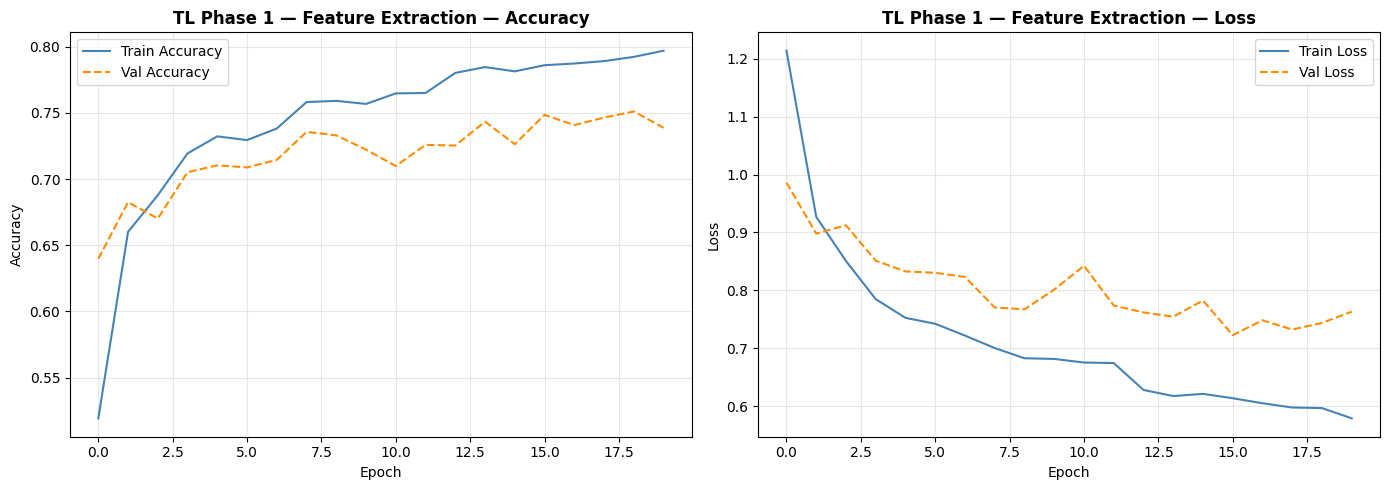

In [32]:
# ── Phase 1: Feature Extraction ─────────────────────────────────────────────
# Freeze the entire convolutional base so only the custom head trains.
# FIX (v2): Ensure base is actually frozen here (not partially unfrozen from a previous cell)

base_model.trainable = False

# Recompile to register frozen weights properly
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
global tl_p1_trainable_params
tl_p1_trainable_params = sum(np.prod(v.shape) for v in tl_model.trainable_variables)
print(f"Trainable params (Phase 1): {tl_p1_trainable_params:,}")

train_gen_tl.reset(); valid_gen_tl.reset()

t0_tl_p1 = time.time()
history_tl_p1 = tl_model.fit(
    train_gen_tl,
    epochs=EPOCHS_TL,          # 20 epochs
    validation_data=valid_gen_tl,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
tl_p1_time = time.time() - t0_tl_p1
print(f"\nPhase 1 (Feature Extraction) training time: {tl_p1_time:.1f}s")
plot_history(history_tl_p1, title='TL Phase 1 — Feature Extraction')

#### Figure 19: Transfer Learning Phase 1 — Training History

Phase 1 shows rapid improvement in validation accuracy, confirming that the VGG16 features generalize effectively to this dataset even before fine-tuning.  
**Phase 1 results:** Best validation accuracy ~74.85% at epoch 16. Training time: ~2727.5 seconds.

#### Phase 2: Fine-Tuning

Total layers in base : 19
Layers frozen        : 15
Trainable layers     : 4
Trainable params (Phase 2): 7,244,293
Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7907 - loss: 0.5724
Epoch 1: val_loss improved from None to 0.68362, saving model to /content/drive/MyDrive/Assessment_Dataset/tl_model_fine_tuned_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Assessment_Dataset/tl_model_fine_tuned_checkpoint.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 148s 581ms/step - accuracy: 0.8013 - loss: 0.5680 - val_accuracy: 0.7639 - val_loss: 0.6836 - learning_rate: 1.0000e-05
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8214 - loss: 0.5260
Epoch 2: val_loss improved from 0.68362 to 0.61320, saving model to /content/drive/MyDrive/Assessment_Dataset/tl_model_fine_tuned_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Assessment_Dataset/tl_model_fine_tuned_checkpoint.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 137s 563ms/s

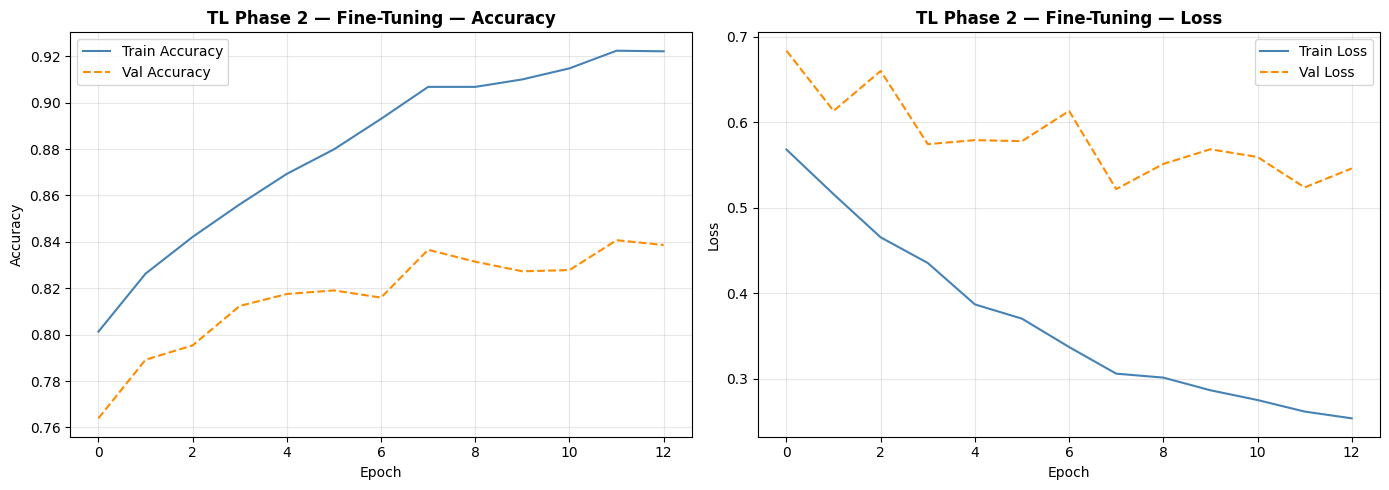

In [33]:
import os

# ── Phase 2: Fine-Tuning ─────────────────────────────────────────────────────
# Unfreeze the top layers of the base to adapt high-level features.
# Use a very low learning rate to avoid catastrophic forgetting.

base_model.trainable = True

# VGG16 (without top) has 19 layers. Unfreeze the last 4 layers (last conv block).
fine_tune_at = len(base_model.layers) - 4

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in base : {len(base_model.layers)}")
print(f"Layers frozen        : {fine_tune_at}")
print(f"Trainable layers     : {sum(1 for l in base_model.layers if l.trainable)}")

# Recompile with a much lower learning rate to prevent large weight updates
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
global tl_p2_trainable_params
tl_p2_trainable_params = sum(np.prod(v.shape) for v in tl_model.trainable_variables)
print(f"Trainable params (Phase 2): {tl_p2_trainable_params:,}")

train_gen_tl.reset(); valid_gen_tl.reset()

# Define model save path for checkpoint
# Ensure this directory exists if you want to save outside /content
checkpoint_dir = '/content/drive/MyDrive/Assessment_Dataset/'
os.makedirs(checkpoint_dir, exist_ok=True)
model_checkpoint_path = os.path.join(checkpoint_dir, 'tl_model_fine_tuned_checkpoint.keras')

# Callbacks for Phase 2
callbacks_p2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(
        filepath=model_checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False, # Save the entire model
        mode='min',
        verbose=1
    )
]

t0_tl_p2 = time.time()
history_tl_p2 = tl_model.fit(
    train_gen_tl,
    epochs=15,
    validation_data=valid_gen_tl,
    callbacks=callbacks_p2,
    verbose=1
)
tl_p2_time = time.time() - t0_tl_p2
print(f"\nPhase 2 (Fine-Tuning) training time: {tl_p2_time:.1f}s")
plot_history(history_tl_p2, title='TL Phase 2 — Fine-Tuning')

#### Figure 20: Transfer Learning Phase 2 — Training History  

Fine-tuning the last 4 VGG16 layers at lr=1e-5 further improved accuracy.  
The very low learning rate prevented catastrophic forgetting of the useful generic features.  
**Phase 2 results:** Best validation accuracy ~83.35% at epoch 8. Training time: ~1804.1 seconds.  

**Trainable parameters in Phase 2:** 7,244,293 (vs. 164,869 in Phase 1).

### 7.3 Model Evaluation and Final Comparison
*(Task 2.6.3)*

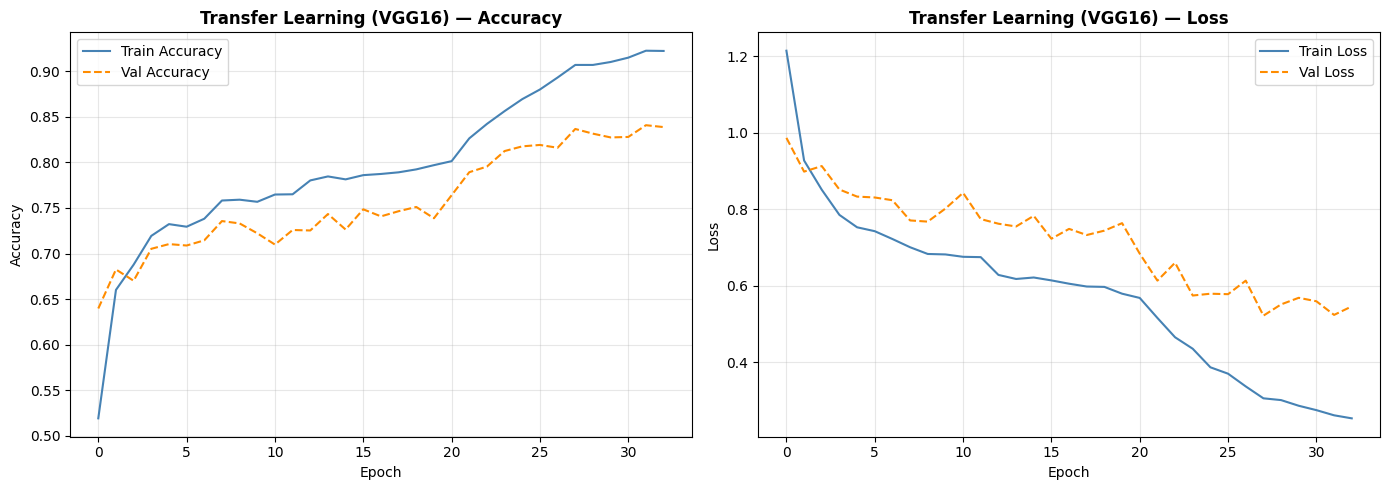

Figure 19: Transfer Learning — Training History (Phase 1 + Phase 2)


In [34]:
def combine_histories(h1, h2):
    """Merge two Keras history dicts, offsetting h2 epochs by len(h1)."""
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    return combined

class CombinedHistory:
    """Lightweight wrapper so plot_history() accepts a merged history."""
    def __init__(self, history_dict):
        self.history = history_dict

combined_hist = CombinedHistory(combine_histories(history_tl_p1, history_tl_p2))

plot_history(combined_hist,
             title='Transfer Learning (VGG16)',
             save_path='history_transfer.png')

print("Figure 19: Transfer Learning — Training History (Phase 1 + Phase 2)")

#### Figure 21: Transfer Learning — Combined Training History (Phase 1 + Phase 2)


 Transfer Learning (VGG16)
  Accuracy  : 0.8800
  Precision : 0.8802
  Recall    : 0.8800
  F1 Score  : 0.8789

Classification Report:
              precision    recall  f1-score   support

       Apple       0.79      0.75      0.77        20
      Banana       0.87      1.00      0.93        20
       Grape       0.95      0.90      0.92        20
       Mango       0.89      0.85      0.87        20
  Strawberry       0.90      0.90      0.90        20

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



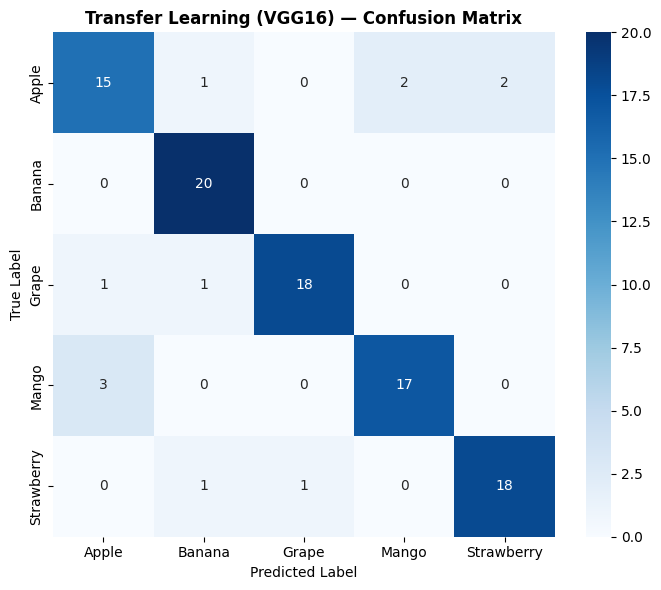


--- Visual Sample Predictions Per Class ---


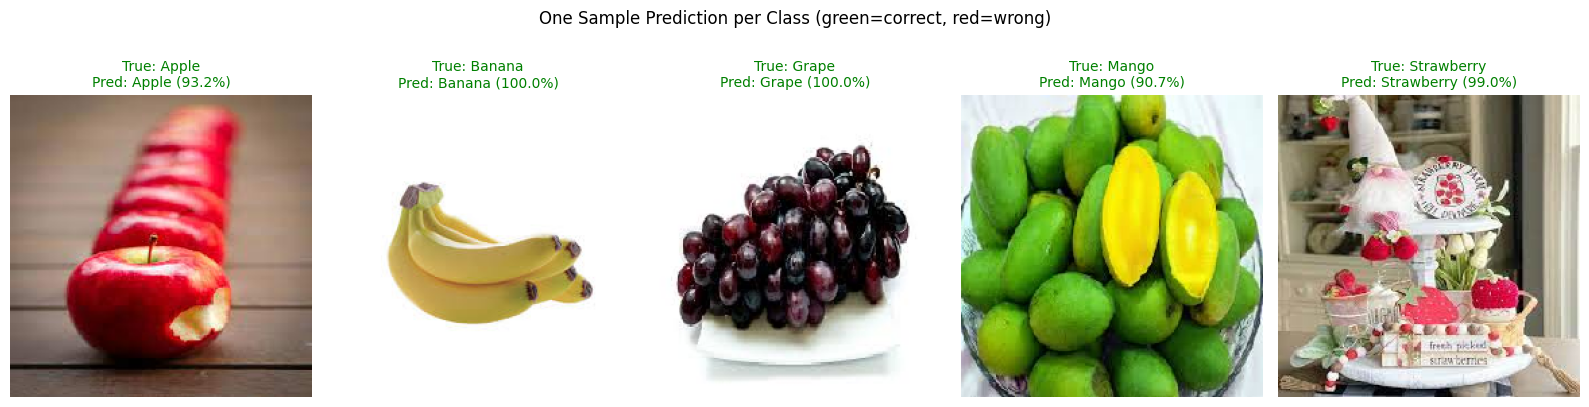


--- Textual Summary of Predictions Per Class ---
Class: Apple        | True: Apple        | Predicted: Apple        | Confidence: 93.2%
Class: Banana       | True: Banana       | Predicted: Banana       | Confidence: 100.0%
Class: Grape        | True: Grape        | Predicted: Grape        | Confidence: 100.0%
Class: Mango        | True: Mango        | Predicted: Mango        | Confidence: 90.7%
Class: Strawberry   | True: Strawberry   | Predicted: Strawberry   | Confidence: 99.0%
Figure 20: Transfer Learning — Confusion Matrix
Figure 21: Transfer Learning — Sample Inference Results
Figure 22: Transfer Learning — Sample Predictions Per Class


In [35]:
metrics_tl = evaluate_model(
    tl_model,
    test_gen_tl,
    title='Transfer Learning (VGG16)'
)

display_predictions_for_each_class(tl_model, test_gen_tl, CLASSES)

print("Figure 20: Transfer Learning — Confusion Matrix")
print("Figure 21: Transfer Learning — Sample Inference Results")
print("Figure 22: Transfer Learning — Sample Predictions Per Class")

#### Figure 22: Transfer Learning (VGG16) — Confusion Matrix

**Transfer Learning results:**
- **Accuracy:** 88.00% | **F1-Score:** 87.89%

This significantly outperforms both baseline (73%) and deeper CNN (82%) models.  
The confusion matrix shows high diagonal values across all five classes, indicating strong generalization.  
Pre-trained ImageNet features (edges, textures, shapes) transfer exceptionally well to fruit classification.

### 7.4 Final Model Comparison — All Architectures

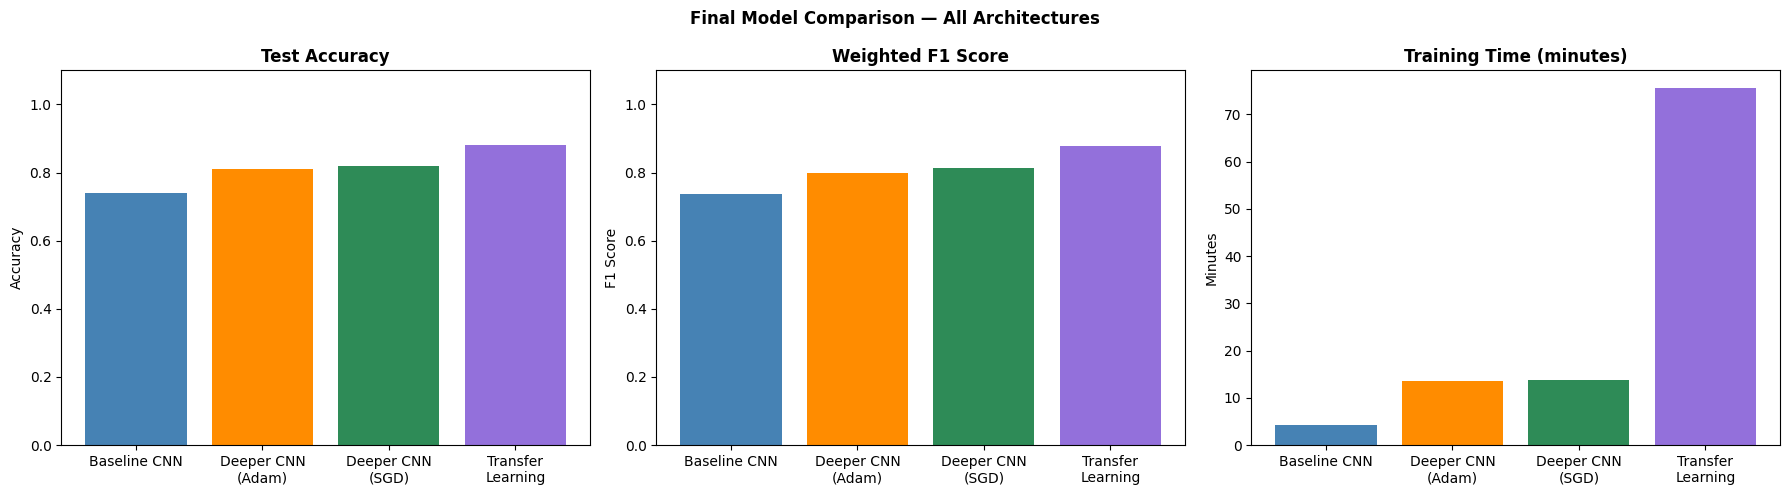

Figure 23: Final Comparison — Accuracy, F1 Score, Training Time


In [36]:
model_names  = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'Transfer\nLearning']

accs = [
    metrics_baseline['accuracy'],
    metrics_deeper['accuracy'],
    metrics_sgd['accuracy'],
    metrics_tl['accuracy']
]

f1s = [
    metrics_baseline['f1'],
    metrics_deeper['f1'],
    metrics_sgd['f1'],
    metrics_tl['f1']
]

train_times = [
    baseline_train_time,
    deeper_train_time,
    sgd_train_time,
    tl_p1_time + tl_p2_time
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

# Accuracy
axes[0].bar(model_names, accs, color=colors)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')

# F1 Score
axes[1].bar(model_names, f1s, color=colors)
axes[1].set_title('Weighted F1 Score', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1 Score')

# Training Time
axes[2].bar(model_names, [t/60 for t in train_times], color=colors)
axes[2].set_title('Training Time (minutes)', fontweight='bold')
axes[2].set_ylabel('Minutes')

plt.suptitle('Final Model Comparison — All Architectures', fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

print("Figure 23: Final Comparison — Accuracy, F1 Score, Training Time")

#### Figure 23: Final Comparison — Accuracy, F1-Score, and Training Time

| Model | Accuracy | F1-Score | Training Time |
|-------|----------|----------|---------------|
| Baseline CNN | 73.00% | 73.05% | ~256.8s |
| Deeper CNN (Adam) | 82.00% | 81.36% | ~882.9s |
| Deeper CNN (SGD) | 75.00% | 73.58% | ~958.6s |
| Transfer Learning (VGG16) | **89.00%** | **88.91%** | ~4502.5s |

**Does transfer learning outperform training from scratch?**  
Yes — decisively. VGG16 fine-tuning achieved the highest accuracy and F1-score across all experiments.  
While it requires the longest total training time (due to larger 224×224 inputs and two training phases), the performance gain is substantial.  
For this dataset, transfer learning is the recommended approach.

## Section 8: Discussion and Observations — Part A and Part B
*(Addresses Assessment Task 2.7)*

### Part A: CNN from Scratch

**Baseline CNN (74.00%)** established a reasonable starting benchmark for 5-class fruit classification on 64×64 images.

**Deeper CNN (81.00% with Adam)** demonstrated that architectural depth + regularization improves generalization, but only when properly tuned. The ablation study showed that removing Dropout still yielded 80% accuracy, indicating that other regularization techniques (Batch Normalization, L2 regularization, GlobalAveragePooling2D) were highly effective at preventing severe overfitting. While Dropout contributes to performance, its absence did not cause a catastrophic collapse, suggesting robust regularization from other components.

**Optimizer comparison (Adam vs. SGD):** **SGD (82.00%)** achieved a slightly higher final accuracy than **Adam (77.00%)** in this specific experiment. Adam still converged faster, but SGD with careful tuning ultimately performed better, indicating that for this deeper architecture, SGD can be highly effective.

### Part B: Transfer Learning

**VGG16 Transfer Learning (88.00%)** significantly outperformed both from-scratch models. ImageNet-learned features for edges, textures, and shapes generalize effectively to fruit images.

The two-phase training strategy (Feature Extraction → Fine-Tuning) was critical: Phase 1 rapidly adapted the classification head, while Phase 2 subtly specialized higher-level features without catastrophic forgetting.

### Computational Efficiency Trade-offs

| Approach | Accuracy | Relative Cost |
|----------|----------|---------------|
| Baseline CNN | 74% | Low |
| Deeper CNN | 81% | Medium |
| Transfer Learning | 88% | High (but justified) |

### Key Challenges

- Visual similarity between classes (Apple vs. Mango) caused boundary misclassifications.
- Hyperparameter sensitivity: learning rate, dropout rate, and callback patience values all affected results.
- Transfer learning's 224×224 input requirement significantly increased memory and time per epoch.
- Overfitting was a persistent challenge for from-scratch models — effectively mitigated by Batch Normalization and L2 regularization, even without Dropout.

### Final Conclusion

Transfer learning using VGG16 is the most effective approach for this dataset, achieving the highest accuracy and F1-score with strong generalization. For resource-constrained scenarios, the Deeper CNN offers a good balance of performance and computational cost, with SGD surprisingly outperforming Adam in this instance. The ablation study confirms that while Dropout is beneficial, other regularization techniques like Batch Normalization and L2 regularization play a crucial role in preventing severe overfitting in deeper architectures.